In [1]:
import jax

jax.config.update("jax_enable_x64", False)
jax.config.update("jax_platform_name", "cpu")
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)

import os
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
import dLux.utils as dlu

import amigo
import dorito

# import astropy

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl

import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

cpu


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "cal_files/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M_189.8', 'F380M_162.7', 'F480M_189.8', 'F480M_162.7'])


In [3]:
optics = amigo.optical_models.AMIOptics()
otf_coords = dlu.pixel_coords(51, 2 * optics.diameter)

ois = [
    dorito.model_fits.ResolvedOIFit(oi_data, key, filter=key[:5])
    for key, oi_data in cal_vis_outputs.items()
]
# ois = [center_phase(oi) for oi in ois]

# distribution = np.zeros((41, 41)).at[20, 20].set(1.0)  # + 1e-16
distribution = np.ones((121, 121))
# distribution = np.zeros((51, 51)).at[25, 25].set(1.0) + 1e-2

model = dorito.models.ResolvedSickoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    # oversample=6.0,
    oversample=6.0,
)

params = model.params
for oi in ois:
    dirty_img = oi.dirty_image(model)
    params["log_dist"][oi.get_key("log_dist")] = np.log10(dirty_img / dirty_img.sum())

In [4]:
# oi = ois[0]

# sz = 99
# delta = np.zeros((sz, sz)).at[sz // 2, sz // 2].set(1.0)
# distribution = delta.at[40, 40].set(0.2).at[53, 53].set(0.3)

# delta /= delta.sum()
# distribution /= distribution.sum()

# base_uv = dlu.MFT(
#     phasor=delta + 0j,
#     wavelength=oi.wavel,  # If focal length is None this doesn't do anything
#     pixel_scale_in=model.pscale_in,
#     npixels_out=model.uv_npixels,
#     pixel_scale_out=model.uv_pscale,
# )

# uv = dlu.MFT(
#     phasor=distribution + 0j,
#     wavelength=oi.wavel,  # If focal length is None this doesn't do anything
#     pixel_scale_in=model.pscale_in,
#     npixels_out=model.uv_npixels,
#     pixel_scale_out=model.uv_pscale,
# )

# uv /= base_uv

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title(f"{oi.filter} u,v amplitude")
# plt.imshow(np.abs(uv), coolwarm, norm=mpl.colors.CenteredNorm(1.00))
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title(f"{oi.filter} u,v phase")
# plt.imshow(np.angle(uv), seismic, norm=mpl.colors.CenteredNorm())
# plt.colorbar()
# plt.show()


# # TO SICKO
# uv = dlu.downsample(uv, 2, mean=True)
# vis = uv.flatten()[: uv.size // 2]
# vis = np.log(vis)
# log_amp, phase = vis.real, vis.imag
# sicko_amp = np.dot(log_amp, oi.vis_mat)
# sicko_phase = np.dot(phase, oi.phi_mat)

# # FROM SICKO
# # converting to u,v visibilities
# log_vis = np.dot(sicko_amp, np.linalg.pinv(oi.vis_mat))
# phase = np.dot(sicko_phase, np.linalg.pinv(oi.phi_mat))
# vis_im, phase_im = amigo.vis_models.vis_to_im(log_vis, phase, (51, 51))
# uv = np.exp(vis_im + 1j * phase_im)

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title(f"{oi.filter} u,v amplitude")
# plt.imshow(np.abs(uv), coolwarm, norm=mpl.colors.CenteredNorm(1.00))
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title(f"{oi.filter} u,v phase")
# plt.imshow(np.angle(uv), seismic, norm=mpl.colors.CenteredNorm())
# plt.colorbar()
# plt.show()


# # Getting the dirty image
# mft_dirty = dlu.MFT(
#     phasor=uv,
#     wavelength=oi.wavel,
#     pixel_scale_in=2 * model.uv_pscale,
#     npixels_out=distribution.shape[0],
#     pixel_scale_out=model.pscale_in,
#     inverse=True,
# )

# dirty = np.abs(mft_dirty)
# dirty /= dirty.sum()

# print(dirty.sum())

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.imshow(distribution, "inferno", norm=mpl.colors.PowerNorm(0.3))
# plt.title("Distribution")
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.imshow(dirty, "inferno", norm=mpl.colors.PowerNorm(0.3))
# plt.title("Dirty Image")
# plt.colorbar()
# plt.show()

In [5]:
# fig, ax = plt.subplots(1, 1)
# im = dorito.plotting.plot_result(
#     ax,
#     ois[0].dirty_image(model, model.get_distribution(ois[0]).shape[0]),
#     dlu.rad2arcsec(model.pscale_in),
# )
# fig.colorbar(im, ax=ax)
# ax.set_title("Dirty Image")
# plt.show()

In [6]:
# for oi in ois:
#     dist = model.get_distribution(oi)
#     plt.imshow(dist)
#     plt.colorbar()
#     plt.show()

In [7]:
import jax.scipy as jsp
import jax.random as jr


def difflim_to_cov(model, exposure, factor):

    # calculating lambda over D
    D = 6.603464  # m
    lambda_on_D = dlu.rad2arcsec(exposure.wavel / D)

    # calculating sigma, with some factor in front of lambda on D
    sigma = dorito.misc.fwhm_to_sigma(factor * lambda_on_D)

    # return covariance matrix
    return [[sigma**2, 0], [0, sigma**2]]


def blur_distribution(array, model, exposure, extent=0.25, factor=1.0):
    cov = difflim_to_cov(model, exposure, factor)

    x = np.arange(-extent, extent, dlu.rad2arcsec(model.pscale_in))
    X, Y = np.meshgrid(x, x)
    pos = np.dstack((X, Y))

    kernel = jsp.stats.multivariate_normal.pdf(jr.PRNGKey(0), pos, np.array(cov))

    distribution = jsp.signal.convolve2d(
        array,
        kernel,
        mode="same",
        # method="fft",
    )
    return distribution / distribution.sum()


# def normalise_distribution(model_params, args):
#     params = model_params.params
#     if "log_dist" in params.keys():
#         for k, log_dist in params["log_dist"].items():
#             distribution = 10**log_dist
#             params["log_dist"][k] = np.log10(distribution / distribution.sum())

#     return model_params.set("params", params), args


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist

            # centre = distribution.shape[0] // 2
            # norm = distribution[centre, centre]

            norm = distribution.sum()

            params["log_dist"][k] = np.log10(distribution / norm)

    return model_params.set("params", params), args


def grad_fn(model, grads, args):

    threshold = 1e-5

    params = grads.params
    if "log_dist" in params.keys():
        for k, grad in params["log_dist"].items():
            grad = np.clip(grad, threshold, threshold)
            params["log_dist"][k] = grad

    return grads.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.5e}")


def log_likelihood(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = np.concatenate([*oi(model)])
    # model_vis = oi(model).flatten()

    # chi2 = np.sum(jax.scipy.stats.norm.logpdf(data, loc=model_vis, scale=err))
    loglike = np.sum(((data - model_vis) / err) ** 2)

    return loglike


def apply_regularisers(model, exposure, args):
    # creating a list of regularisation functions and regularisation hyperparameters
    fn_list = [args["reg_func_dict"][reg] for reg in args["reg_dict"].keys()]
    coeff_list = list(args["reg_dict"].values())

    # evaluating the regularisation term with each for each regulariser
    priors = [
        coeff * fn(model, exposure, args) for coeff, fn in zip(coeff_list, fn_list)
    ]
    prior = np.array(priors).sum()  # summing the different regularisers

    return prior


def calc_loglike_prior(model, exposure, args):
    # this is per exposure

    # regular likelihood term
    likelihood = np.nanmean(log_likelihood(model, exposure))

    # grabbing and exponentiating log distributions
    prior = apply_regularisers(model, exposure, args)

    return likelihood, prior


def regularised_loss_fn(model, exposure, args={"reg_func_dict": {}, "reg_dict": {}}):
    # this is per exposure
    likelihood, prior = calc_loglike_prior(model, exposure, args)
    return likelihood + prior, ()
    # return likelihood + prior


def phase_centre(model, oi, args={}):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    _log_amp, phase = oi.to_logvis(model, distribution)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-3):
    likelihood, prior = calc_loglike_prior(model, exposure, args)

    # phase centre prior
    centre = phase_centre(model, exposure, args)
    prior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return likelihood + prior, ()


import equinox as eqx
import optimistix as optx


def BFGS_logdist(model, exposures, reg_args, max_steps=2**14):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss, _ = regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = model.params["log_dist"][exp.get_key("log_dist")]
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = optx.BFGS(rtol=1e-4, atol=1e-4)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [8]:
# oi = ois[0]
# # distribution = np.zeros((121, 121)).at[80, 60].set(1.0)
# distribution = result.model.get_distribution(oi)

# otf = oi.to_otf(model, distribution)

# amp_im = np.abs(otf)
# phase_im = np.angle(otf)


# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title("Amplitude")
# plt.imshow(amp_im, inferno)
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title("Phase")
# plt.imshow(phase_im, "twilight")
# plt.colorbar()
# plt.show()

# plt.figure(figsize=(2, 2))
# plt.imshow(distribution, "inferno")
# # plt.colorbar()
# plt.title("Distribution")
# plt.axis("off")
# plt.show()

# log_amp, phase = oi.to_logvis(model, distribution)

# # Transform to the sicko basis
# sicko_amp = np.dot(log_amp, oi.vis_mat)
# sicko_phase = np.dot(phase, oi.phi_mat)

# print(sicko_amp[-2], sicko_phase[-2])
# print(sicko_amp[-1], sicko_phase[-1])

In [10]:
# # @zdx.filter_jit
# @zdx.filter_grad("log_dist")
# def loss(model_params, model, exposure, args={"reg_func_dict": {}, "reg_dict": {}}):
#     model = model_params.inject(model)
#     return regularised_loss_fn(model, exposure, args)[0]


# # loss(model, ois[0])

# import optax

# jax.config.update("jax_debug_nans", True)


# config = {"log_dist": sgd(1e-1000, 0)}

# model_params = amigo.core_models.ModelParams({p: model.get(p) for p in config.keys()})

# opt_state = solver.init(params)
# for i in range(5):
#     print(f"Iteration {i + 1}")
#     grad = loss(model_params, model, ois[0])
#     updates, opt_state = solver.update(grad, opt_state, model_params)
#     model_params = zdx.apply_updates(model_params, updates)

#     # plt.imshow(model_params.params["log_dist"][ois[0].get_key("log_dist")], inferno)
#     # plt.colorbar()
#     # plt.title("Log Distribution")
#     # plt.show()

#     plt.imshow(grad.params["log_dist"][ois[0].get_key("log_dist")], inferno)
#     plt.colorbar()
#     plt.title("Log Distribution")
#     plt.show()

In [11]:
# from amigo.fisher import FIM
# import equinox as eqx
# import zodiax as zdx
# import time
# from datetime import timedelta
# import jax.tree as jtu
# from amigo.core_models import ModelParams, ParamHistory
# from amigo.fisher import calc_fishers
# from amigo.misc import tqdm
# from amigo.stats import covariance_model
# import optax
# import jax
# import jax.numpy as np
# from jax import config
# import jax.random as jr
# import dLux.utils as dlu


# def scheduler(lr, start, *args):
#     shed_dict = {start: 1e100}
#     for start, mul in args:
#         shed_dict[start] = mul
#     return optax.piecewise_constant_schedule(lr / 1e100, shed_dict)


# base_sgd = lambda vals: optax.sgd(vals, nesterov=True, momentum=0.6)
# base_adam = lambda vals: optax.adam(vals)

# sgd = lambda lr, start, *schedule: base_sgd(scheduler(lr, start, *schedule))
# adam = lambda lr, start, *schedule: base_adam(scheduler(lr, start, *schedule))


# def debug_nan_check(grads):
#     bool_tree = jax.tree_map(lambda x: np.isnan(x).any(), grads)
#     vals = np.array(jax.tree_util.tree_flatten(bool_tree)[0])
#     eqx.debug.breakpoint_if(vals.sum() > 0)
#     return grads


# def zero_nan_check(grads):
#     return jax.tree_map(lambda x: np.where(np.isnan(x), 0.0, x), grads)


# def set_array(pytree, parameters):
#     dtype = np.float64 if config.x64_enabled else np.float32
#     floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
#     floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
#     return eqx.combine(floats, other)


# def get_optimiser(model_params, optimisers):
#     param_spec = ModelParams({param: param for param in list(model_params.keys())})
#     optim = optax.multi_transform(optimisers, param_spec)
#     return optim, optim.init(model_params)


# def get_random_batch_order(batches, epochs, args):
#     """Exposures is a dictionary of lists"""
#     # Generate a random order for the batches to be fed
#     key, subkey = jr.split(args["key"], 2)
#     args["key"] = subkey

#     # This is the number of batches we have
#     inds = np.tile(np.arange(len(batches)), (epochs, 1))

#     # Permutate the oder of each individual batch
#     batch_inds = jr.permutation(subkey, inds, axis=1, independent=True)
#     return batch_inds, args


# # Returns the batched and gradded loss function
# def get_val_grad_fn(loss_fn):

#     # Injects the model parameters, and takes the loss over the batch, and applied
#     # the gradient transformation
#     def _val_grad_fn(model_params, model, exposures, args):
#         model = model_params.inject(model)
#         keys = [exp.key for exp in exposures]
#         losses, aux = zip(*[loss_fn(model, exp, args) for exp in exposures])
#         return np.array(losses).sum(), dict(zip(keys, aux))

#     return eqx.filter_value_and_grad(_val_grad_fn, has_aux=True)


# # Returns the jitted the loss function
# def get_norm_loss_fn(val_grad_fn, grad_fn=None):

#     @eqx.filter_jit
#     def _norm_loss_fn(model_params, lr_model, model, batch, args):
#         print("Compiling Loss function...")
#         # loss, grads = val_grad_fn(model_params, model, batch, args)
#         (loss, aux), grads = val_grad_fn(model_params, model, batch, args)

#         # Apply the lr normalisation
#         grads = jtu.map(lambda x, y: x * y, grads, lr_model)

#         # Apply user normalisation if exists
#         if grad_fn is not None:
#             grads, args = grad_fn(model, grads, args)
#         return loss, grads, args, aux

#     # return eqx.debug.assert_max_traces(_norm_loss_fn, max_traces=3)
#     return _norm_loss_fn


# # Returns the jitted the update function
# def get_update_fn(optim, norm_fn=None):

#     # Inner function simply binds the optim object from self
#     # @eqx.filter_jit
#     def update_fn(param_grads, model_params, opt_state, args):
#         print("Compiling update function...")
#         # NOTE: We apply the normalisation after calculating the state, so we should
#         # re-update the opt_state to reflect this. Im not sure how this would affect
#         # the opt_state object though

#         # Update the regular parameters and append to history
#         plt.imshow(param_grads.params["log_dist"]["F380M"], inferno)
#         plt.colorbar()
#         plt.title("Log Distribution Gradient")
#         plt.show()

#         plt.imshow(model_params.params["log_dist"]["F380M"], inferno)
#         plt.colorbar()
#         plt.title("Log Distribution")
#         plt.show()

#         updates, opt_state = optim.update(param_grads, opt_state, model_params)
#         model_params = zdx.apply_updates(model_params, updates)

#         if norm_fn is not None:
#             model_params, args = norm_fn(model_params, args)
#         return model_params, opt_state, args

#     return update_fn


# def populate_lr_model(fishers, exposures, model_params):

#     # Build the lr model structure
#     params_dict = jtu.map(lambda x: np.zeros((x.size, x.size)), model_params).params

#     # Loop over exposures
#     for exp in exposures:

#         # Loop over parameters
#         for param in model_params.keys():

#             # Check if the fishers have values for this exposure
#             key = f"{exp.key}.{param}"
#             if key not in fishers.keys():
#                 continue

#             # Add the Fisher matrices
#             if isinstance(params_dict[param], dict):
#                 params_dict[param][exp.get_key(param)] += fishers[key]
#             else:
#                 params_dict[param] += fishers[key]

#     fisher_params = model_params.set("params", params_dict)

#     # Convert fisher to lr model
#     def inv_fn(fmat, leaf):
#         return dlu.nandiv(-1, np.diag(fmat), fill=1).reshape(leaf.shape)

#     return jtu.map(inv_fn, fisher_params, model_params)


# def batch_exposures(exposures, n_batch=None, batch_size=None, key="batch"):
#     # Both have a value
#     if n_batch is not None and batch_size is not None:
#         raise ValueError

#     if key is None:
#         key = "batch_"
#     else:
#         key += "_"

#     # Both None
#     if n_batch is None and batch_size is None:
#         batch_size = len(exposures)

#     # We have batch size, need n_batch
#     if n_batch is None:
#         n_batch = np.ceil(len(exposures) / batch_size).astype(int)

#     # We have n_batch, need batch size
#     if batch_size is None:
#         batch_size = np.ceil(len(exposures) / n_batch).astype(int)
#         n_batch = np.minimum(n_batch, np.ceil(len(exposures) / batch_size).astype(int))

#     # Populate the batches
#     batches = {}
#     for i in range(n_batch):
#         start = i * batch_size
#         end = np.minimum(start + batch_size, len(exposures))
#         batches[f"{key}{i}"] = exposures[start:end]
#     return batches


# def loss_fn(model, exposure, args=None):
#     return -np.nanmean(exposure.mv_zscore(model)), ()


# class Trainer(zdx.Base):
#     fishers: dict
#     loss_fn: callable
#     args_fn: callable
#     grad_fn: callable
#     norm_fn: callable
#     looper_fn: callable
#     aux_fn: callable
#     cache: str

#     def __init__(
#         self,
#         loss_fn=loss_fn,
#         args_fn=None,
#         grad_fn=None,
#         norm_fn=None,
#         looper_fn=None,
#         aux_fn=None,
#         cache="cache",
#     ):
#         """
#         loss_fn(model, exposure, args): -> loss
#         args_fn(model, args, key, epoch): -> (mode, args, key)
#         grad_fn(model, grads, args, key): -> (grads, key)
#         norm_fn(model_params, args, key): -> model_params, key
#         looper_fn(looper, loss_dict): -> ()
#         """
#         self.loss_fn = loss_fn
#         self.args_fn = args_fn
#         self.grad_fn = grad_fn
#         self.norm_fn = norm_fn
#         self.looper_fn = looper_fn
#         self.aux_fn = aux_fn
#         self.fishers = None
#         self.cache = cache

#     def default_looper(self, looper, loss_dict):
#         loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
#         looper.set_description(f"Loss: {loss:.2f}")

#     def populate_fishers(self, model, exposures, hessians, parameters):
#         fishers = {}
#         for exp in exposures:
#             flux_ratio = exp.nints * (exp.ngroups - 1) / exp.ngroups
#             flux = flux_ratio * 10 ** model.get(exp.map_param("fluxes"))
#             for param in parameters:
#                 try:
#                     hess = hessians[param][exp.filter]
#                     hess *= -flux / 80**2

#                     # Match the piston gradient nuking for aberrations
#                     if param == "aberrations":
#                         hess = hess.at[:, 0].set(0)
#                         hess = hess.at[0, :].set(0)

#                     # Reduce the Hessian down to the number of vis_basis terms
#                     if param == "amplitudes" or param == "phases":
#                         n_basis = model.vis_model.n_basis
#                         hess = hess[:n_basis, :n_basis]

#                     # Add the hessian to the fishers
#                     fishers[f"{exp.key}.{param}"] = hess
#                 except KeyError:
#                     print(f"KeyError: {param} not in hessians for {exp.key}, skipped")
#         return self.set("fishers", fishers)

#     def update_fishers(
#         self,
#         model,
#         exposures,
#         parameters=[],
#         recalculate=False,
#         overwrite=True,
#         verbose=True,
#         save=True,
#         args=None,
#         # reduce_ram=False,
#         batch_size=None,
#     ):
#         # RANDOM TODO: Models params should be renamed ParamsDict everywhere and always
#         # Use the dark current data to get a measure of the read noise

#         if batch_size is None:
#             batch_size = 1
#             reduce_ram = False
#         else:
#             reduce_ram = True

#         def fisher_fn(model, exposure, param):
#             slopes, cov = covariance_model(model, exposure)
#             exposure = exposure.set(["slopes", "cov"], [slopes, cov])

#             # NOTE: FIM doesnt return aux, so even though has_aux=True, it wont be returned
#             if args is not None:
#                 fmat = FIM(
#                     model,
#                     param,
#                     self.loss_fn,
#                     exposure,
#                     args,
#                     reduce_ram=reduce_ram,
#                     has_aux=True,
#                     batch_size=batch_size,
#                 )
#             else:
#                 fmat = FIM(
#                     model,
#                     param,
#                     self.loss_fn,
#                     exposure,
#                     reduce_ram=reduce_ram,
#                     has_aux=True,
#                     batch_size=batch_size,
#                 )

#             return -fmat

#         # Calculate the fishers
#         fishers = calc_fishers(
#             model,
#             exposures,
#             parameters,
#             fisher_fn=fisher_fn,
#             overwrite=overwrite,
#             recalculate=recalculate,
#             verbose=verbose,
#             save=save,
#             cache=f"{self.cache}/fishers",
#         )

#         # The second dictionary (new fishers) will overwrite the existing fishers
#         if self.fishers is not None:
#             return self.set("fishers", {**self.fishers, **fishers})
#         return self.set("fishers", fishers)

#     def finalise(
#         self,
#         t0,
#         model,
#         loss_dict,
#         aux,
#         model_params,
#         history,
#         lr_model,
#         epochs,
#         success,
#     ):
#         """Prints stats and returns the result object"""
#         # Final execution time
#         elapsed_time = time.time() - t0
#         formatted_time = str(timedelta(seconds=int(elapsed_time)))
#         print(f"Full Time: {formatted_time}")

#         # Get the final loss
#         final_loss = np.array([losses[-1] for losses in loss_dict.values()]).mean()
#         print(f"Final Loss: {final_loss:,.2f}")

#         # Return
#         return Result(
#             losses=loss_dict,
#             model=model_params.inject(model),
#             aux=aux,
#             state=model_params,
#             history=history,
#             lr_model=lr_model,
#             meta_data={
#                 "elapsed_time": formatted_time,
#                 "epochs": epochs,
#                 "successful": success,
#             },
#         )

#     def unwrap_batches(self, batches):
#         # Format the batches and exposures
#         if isinstance(batches, list):
#             exposures = batches
#             batches = {0: exposures}
#         else:
#             exposures = []
#             for batch_key, batch in batches.items():
#                 exposures += batch
#         return batches, exposures

#     def initial_print(self, loss_dict):
#         # Get the initial loss
#         initial_loss = np.array([losses[-1] for losses in loss_dict.values()]).mean()
#         print(f"\nInitial_loss Loss: {initial_loss:,.2f}")

#     def second_print(self, t1, epochs):
#         estimated_time = epochs * (time.time() - t1)
#         formatted_time = str(timedelta(seconds=int(estimated_time)))
#         print(f"Estimated run time: {formatted_time}")

#     def check_args_key(self, args):
#         # Ensure args key exists and is the right type
#         if "key" in args.keys():
#             if not isinstance(args["key"], (type(jr.key(0)), type(jr.PRNGKey(0)))):
#                 raise ValueError("the 'key' entry of 'args' must be a jax prng key.")
#         if "key" not in args.keys():
#             args["key"] = jr.key(0)
#         return args

#     def train(
#         self,
#         model,
#         optimisers,
#         epochs,
#         batches: dict,
#         args={},
#     ):
#         # Ensure args key exists and is the right type
#         args = self.check_args_key(args)

#         # Get the batches and raw exposures
#         batches, exposures = self.unwrap_batches(batches)

#         # Get the model parameters
#         model_params = ModelParams({p: model.get(p) for p in optimisers.keys()})
#         lrs = populate_lr_model(self.fishers, exposures, model_params)

#         # Get the optax optimiser and history bits
#         optim, state = get_optimiser(model_params, optimisers)
#         history = ParamHistory(model_params)

#         # Get the loss and update functions
#         val_grad_fn = get_val_grad_fn(self.loss_fn)
#         loss_fn = get_norm_loss_fn(val_grad_fn, self.grad_fn)
#         update_fn = get_update_fn(optim, self.norm_fn)

#         # Looping things
#         t0 = time.time()
#         looper = tqdm(range(0, epochs))
#         loss_dict = dict([(key, []) for key in batches.keys()])
#         aux_dict = {}

#         # Loop
#         for epoch in looper:
#             if epoch == 1:
#                 t1 = time.time()

#             if self.args_fn is not None:
#                 model, args = self.args_fn(model, args, epoch)

#             # Create an empty gradient model to append gradients to
#             grads = model_params.map(lambda x: x * 0.0)

#             # Loop over randomised batch order
#             for batch_key, batch in batches.items():
#                 # Calculate the loss and gradients
#                 loss, new_grads, args, aux = loss_fn(
#                     model_params, lrs, model, batch, args
#                 )
#                 grads += new_grads

#                 # Append the mean batch loss to the loss dictionary and update aux dict
#                 loss_dict[batch_key].append(loss / len(batch))

#                 #
#                 if self.aux_fn is not None:
#                     aux_dict = self.aux_fn(aux_dict, aux)

#                 # Check for NaNs and exit if so
#                 if np.isnan(loss):
#                     print(f"Loss is NaN on epoch {epoch}, exiting fit")
#                     return self.finalise(
#                         t0,
#                         model,
#                         loss_dict,
#                         aux,
#                         model_params,
#                         history,
#                         lrs,
#                         epochs,
#                         False,
#                     )

#             model_params, state, args = update_fn(grads, model_params, state, args)
#             history = history.append(model_params)

#             # Update the looper
#             loop_fn = self.default_looper if self.looper_fn is None else self.looper_fn
#             loop_fn(looper, loss_dict)

#             # Print helpful things run time
#             if epoch == 0:
#                 self.initial_print(loss_dict)
#             if epoch == 1:
#                 self.second_print(t1, epochs)

#         # Print the runtime stats and return Result object
#         return self.finalise(
#             t0, model, loss_dict, aux, model_params, history, lrs, epochs, True
#         )


# class Result(zdx.Base):
#     losses: dict
#     model: zdx.Base
#     state: ModelParams
#     lr_model: ModelParams
#     history: ParamHistory
#     aux: dict
#     meta_data: dict

#     def __init__(self, losses, model, aux, state, history, lr_model, meta_data=None):
#         self.losses = losses
#         self.model = model
#         self.state = state
#         self.history = history
#         self.lr_model = lr_model
#         self.meta_data = meta_data
#         self.aux = aux

In [ ]:
jax.config.update("jax_debug_nans", True)
import optax

n_epoch = 5000

config = {
    # "log_dist": sgd(1e-8, 0, (3000, 0.1)),
    # "log_dist": sgd(3e-800, 0),
    "log_dist": optax.sgd(1e-10, 0),
    # "log_dist": sgd(5e-8, 0)  # (100, 10), (2000, 0.5)),
    # "log_dist": adam(1e-2, 0, (500, 2)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        "ME": 1e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 5e6,
    },
}

trainer = amigo.fitting.Trainer(
    # trainer = Trainer(
    # loss_fn=regularised_loss_fn,
    loss_fn=centered_loss_fn,
    # cache=fisher_cache,
    # grad_fn=grad_fn,s
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 64,367,740.00
Estimated run time: 0:01:22


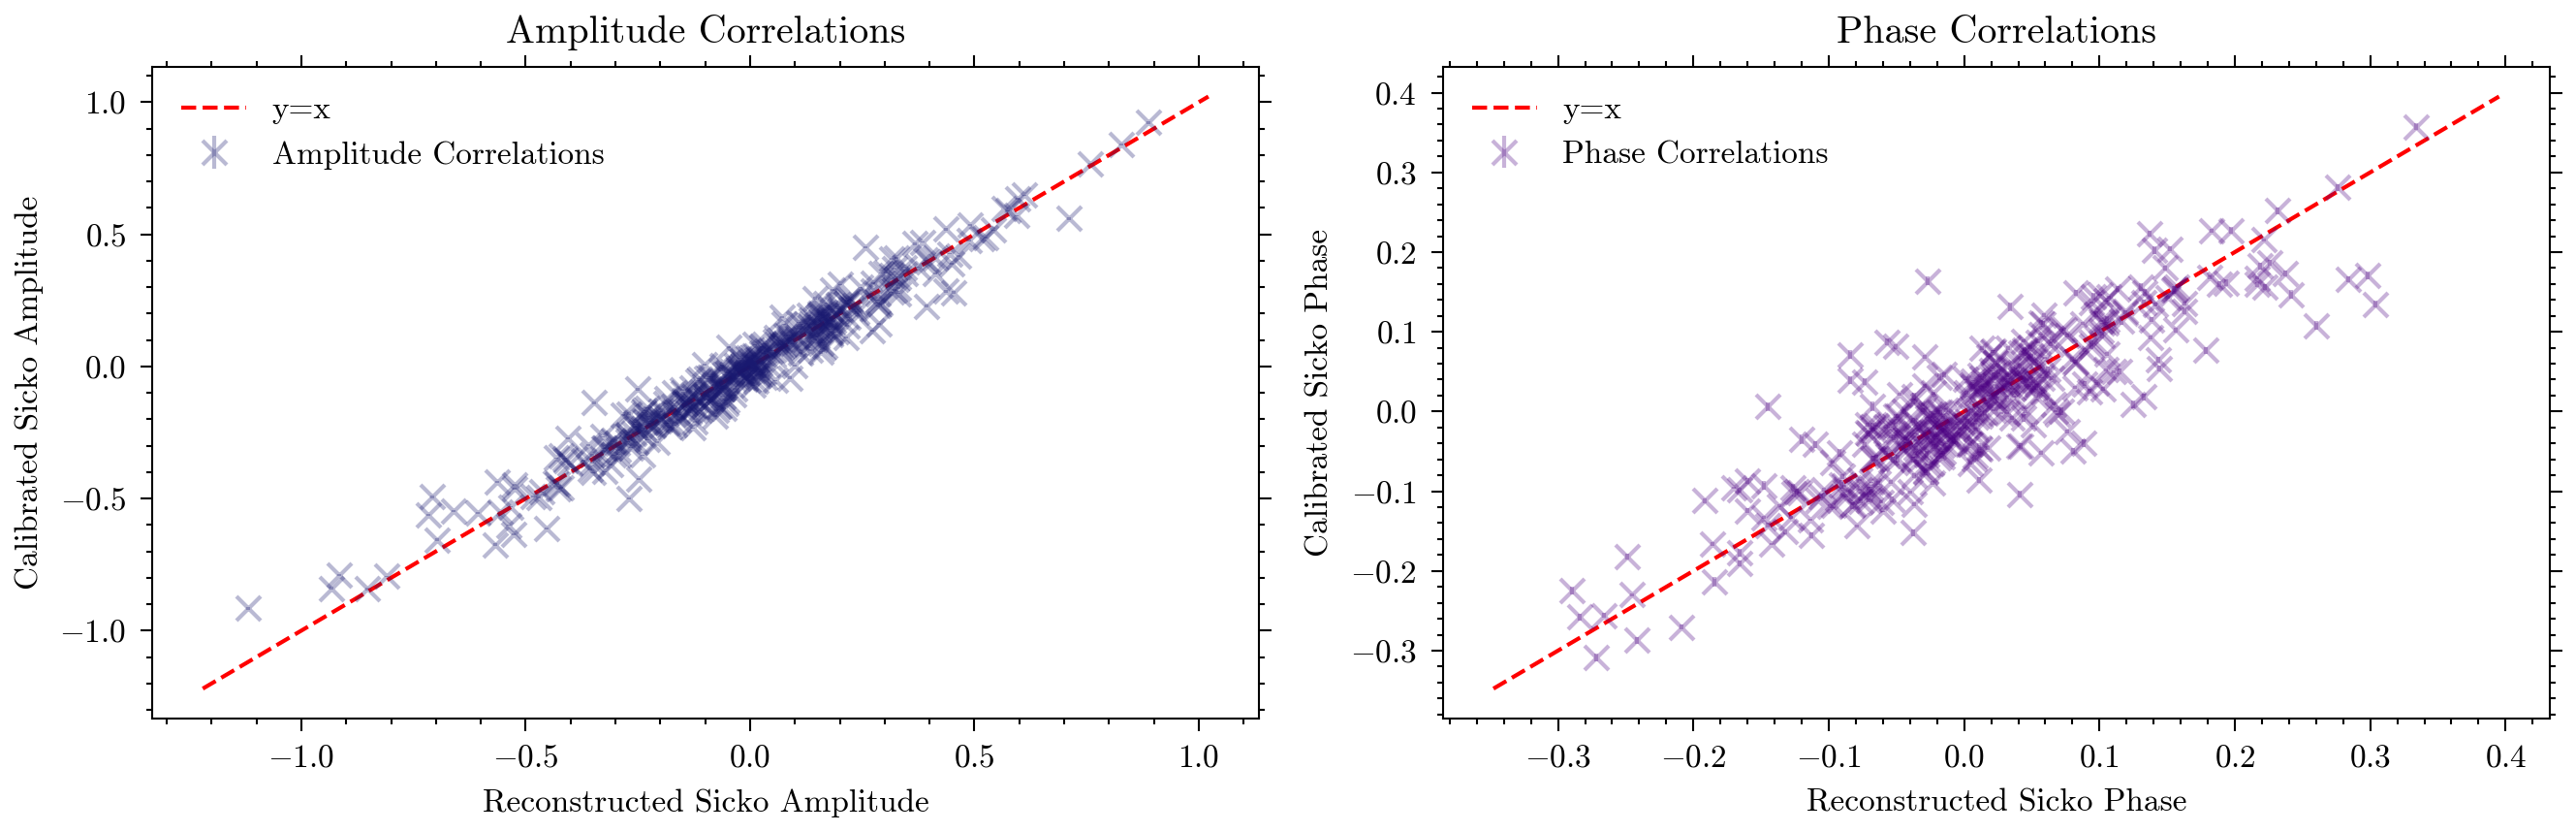

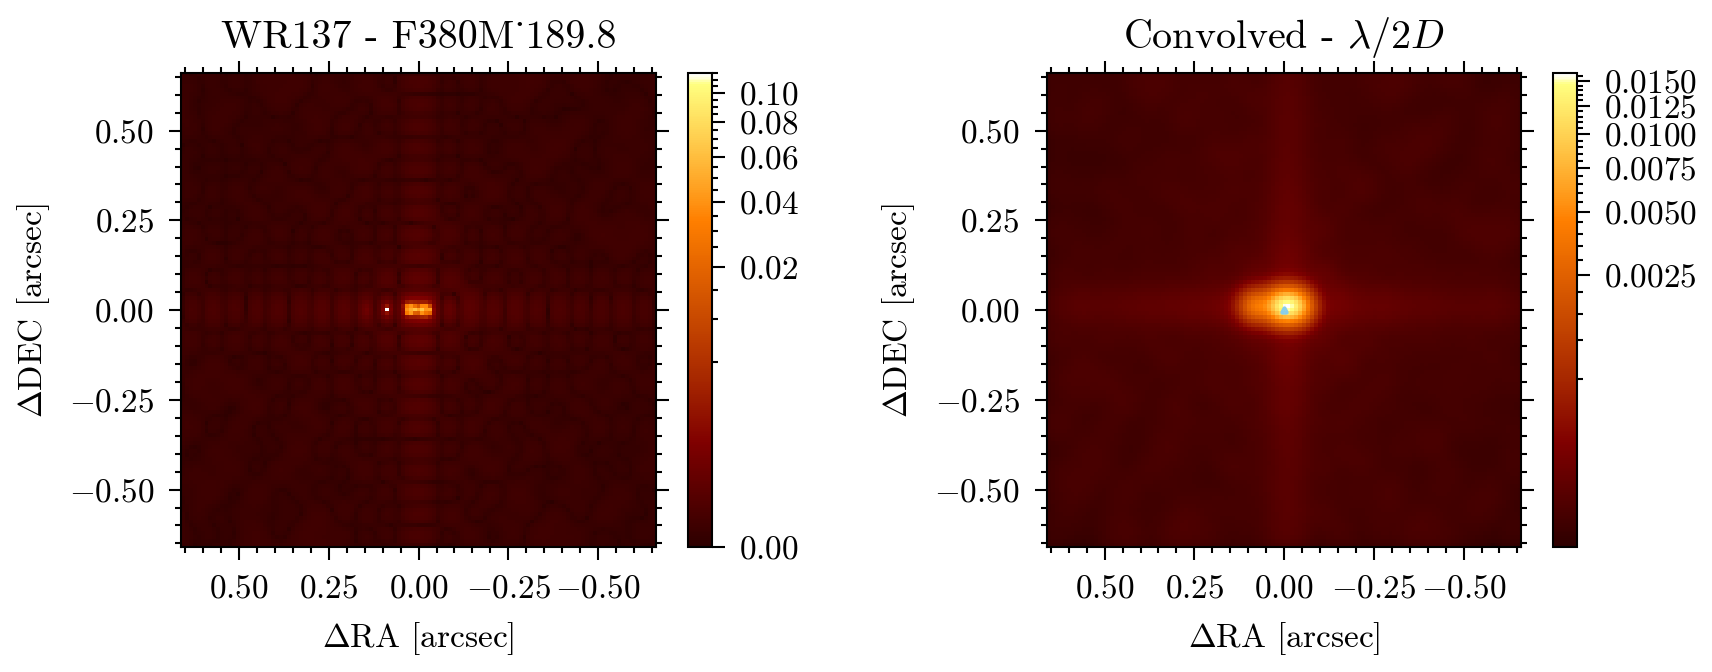

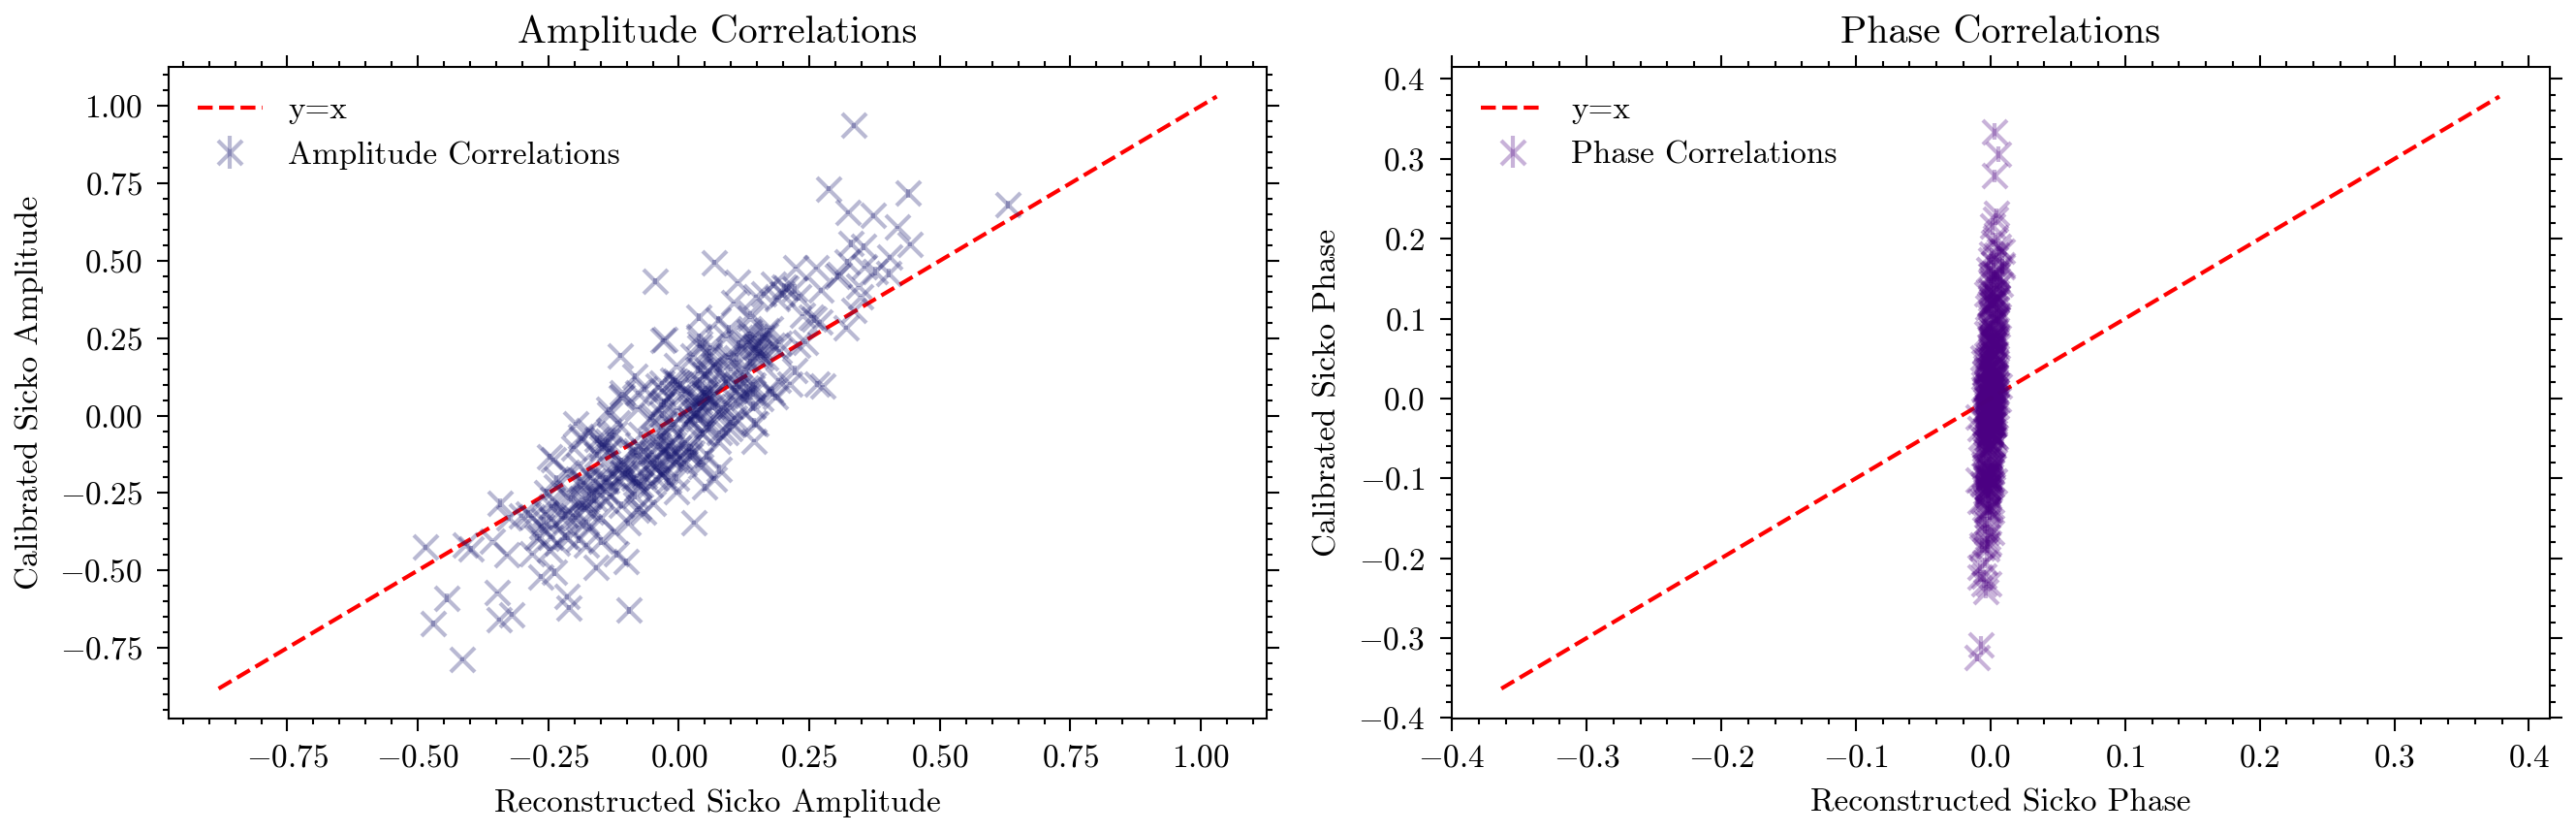

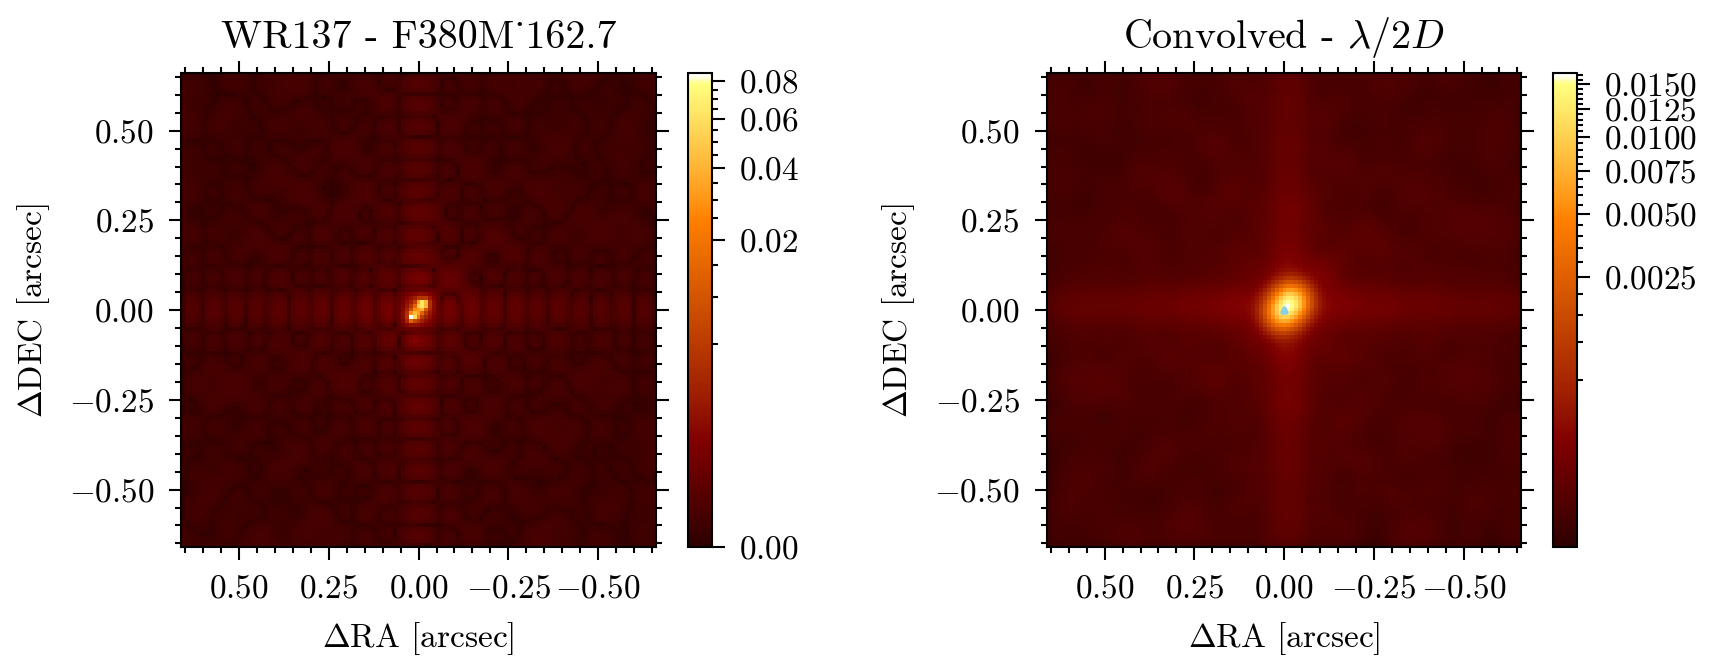

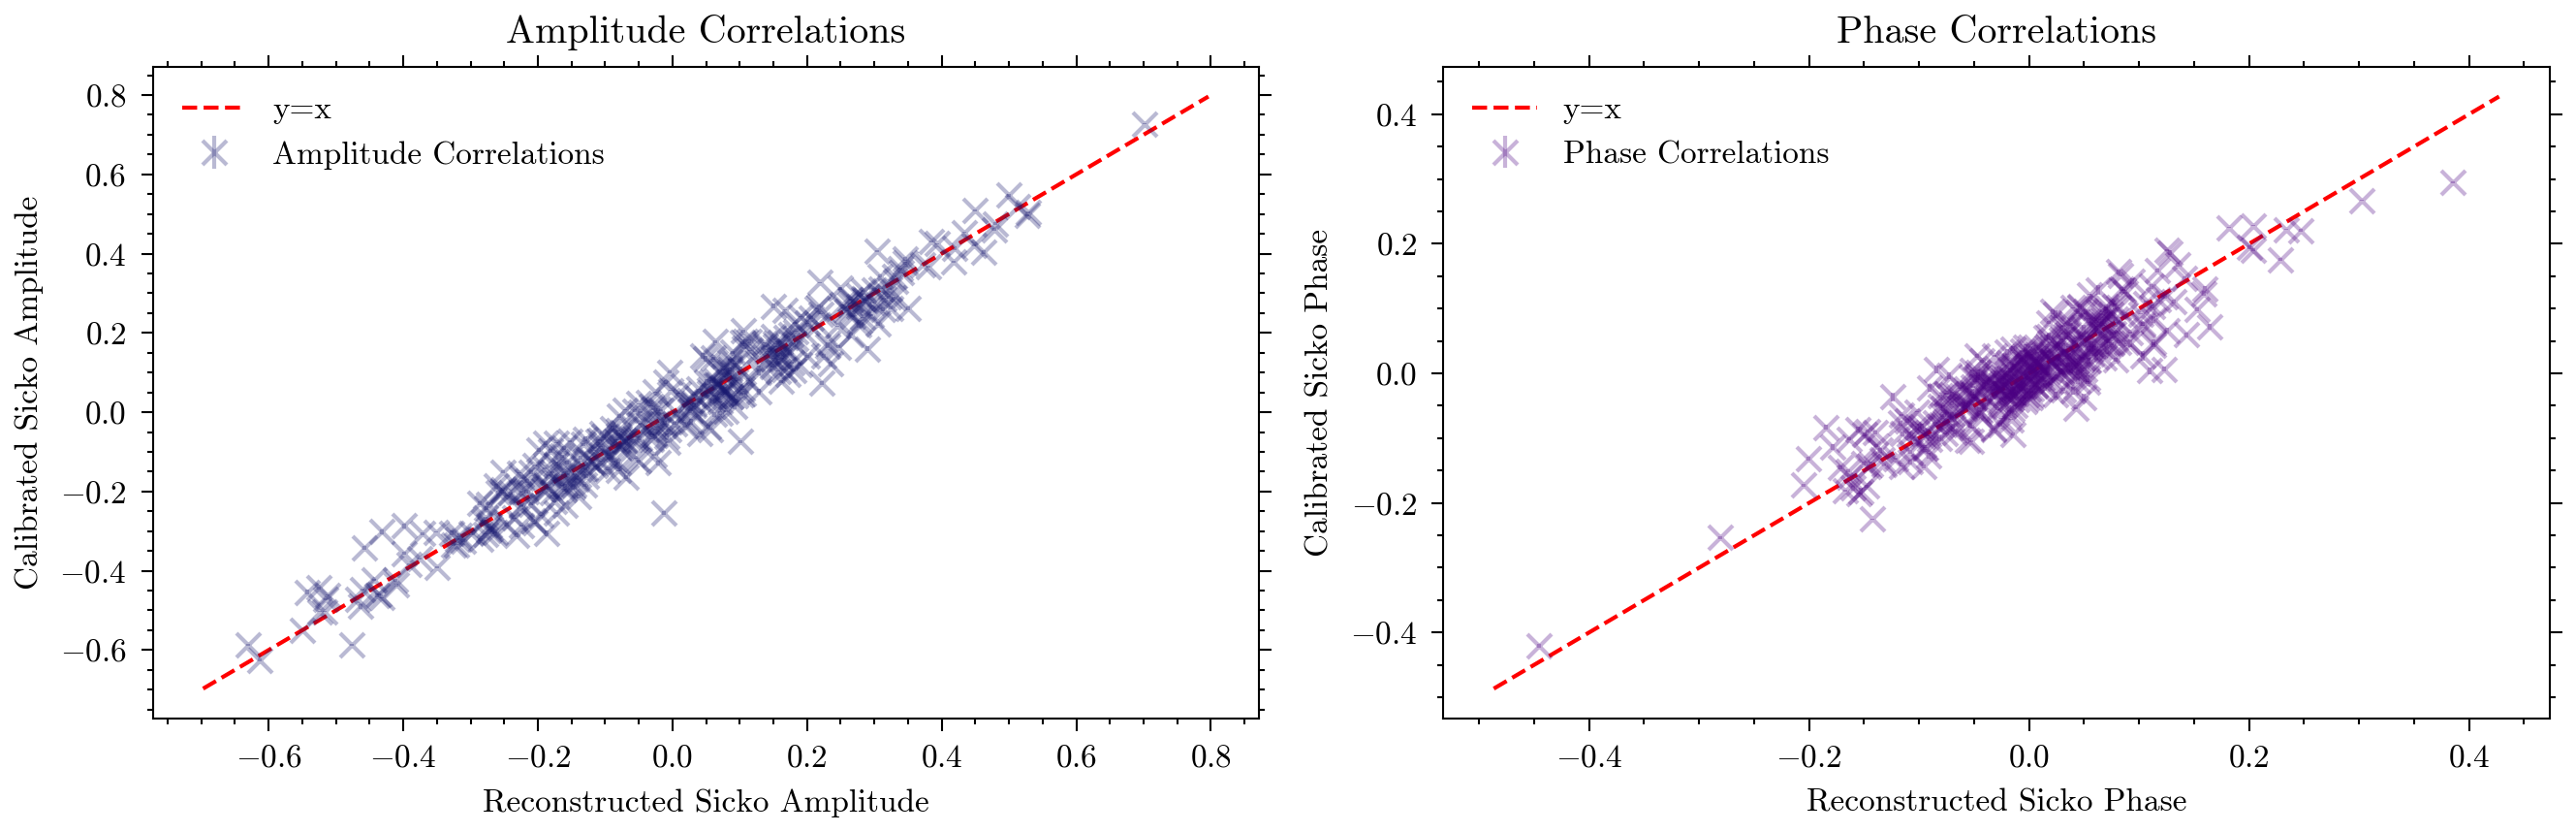

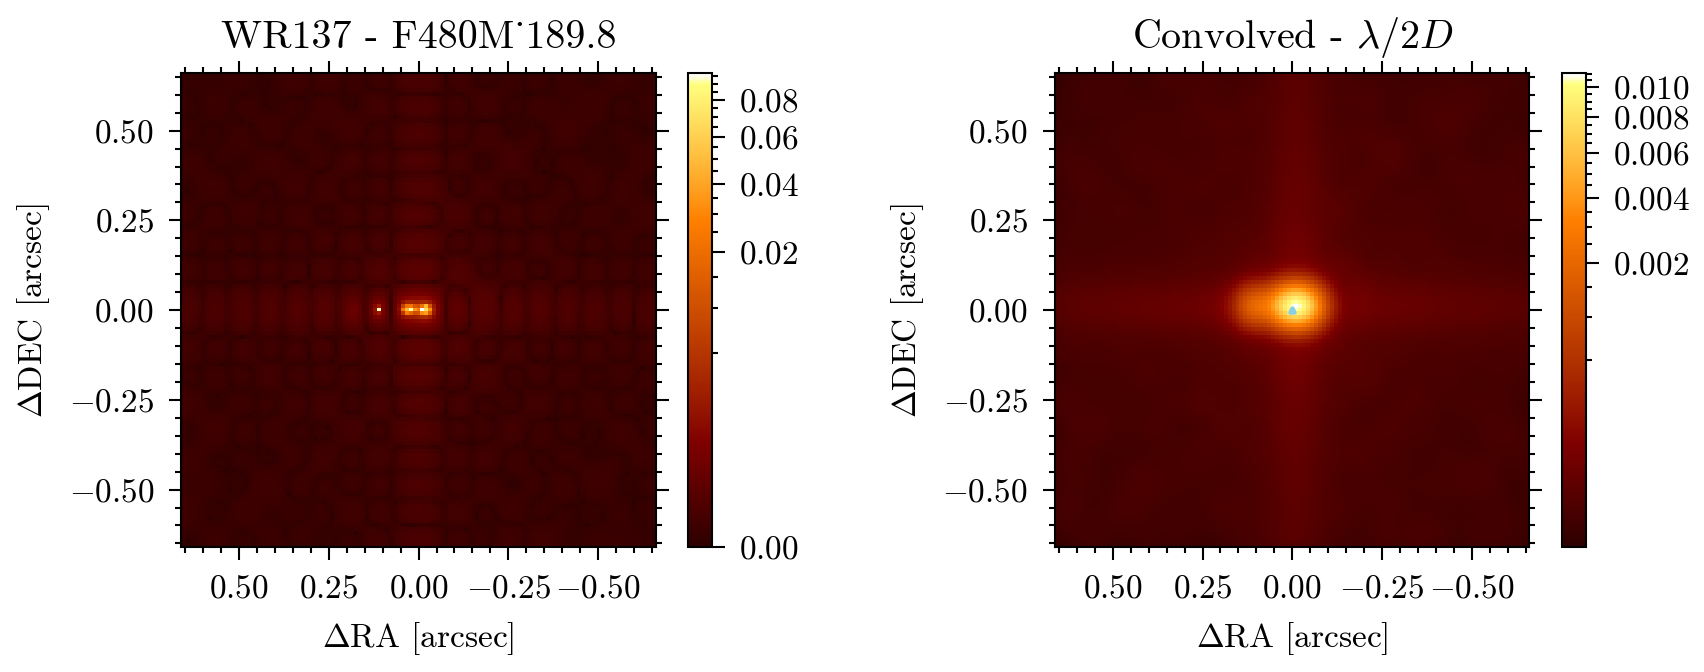

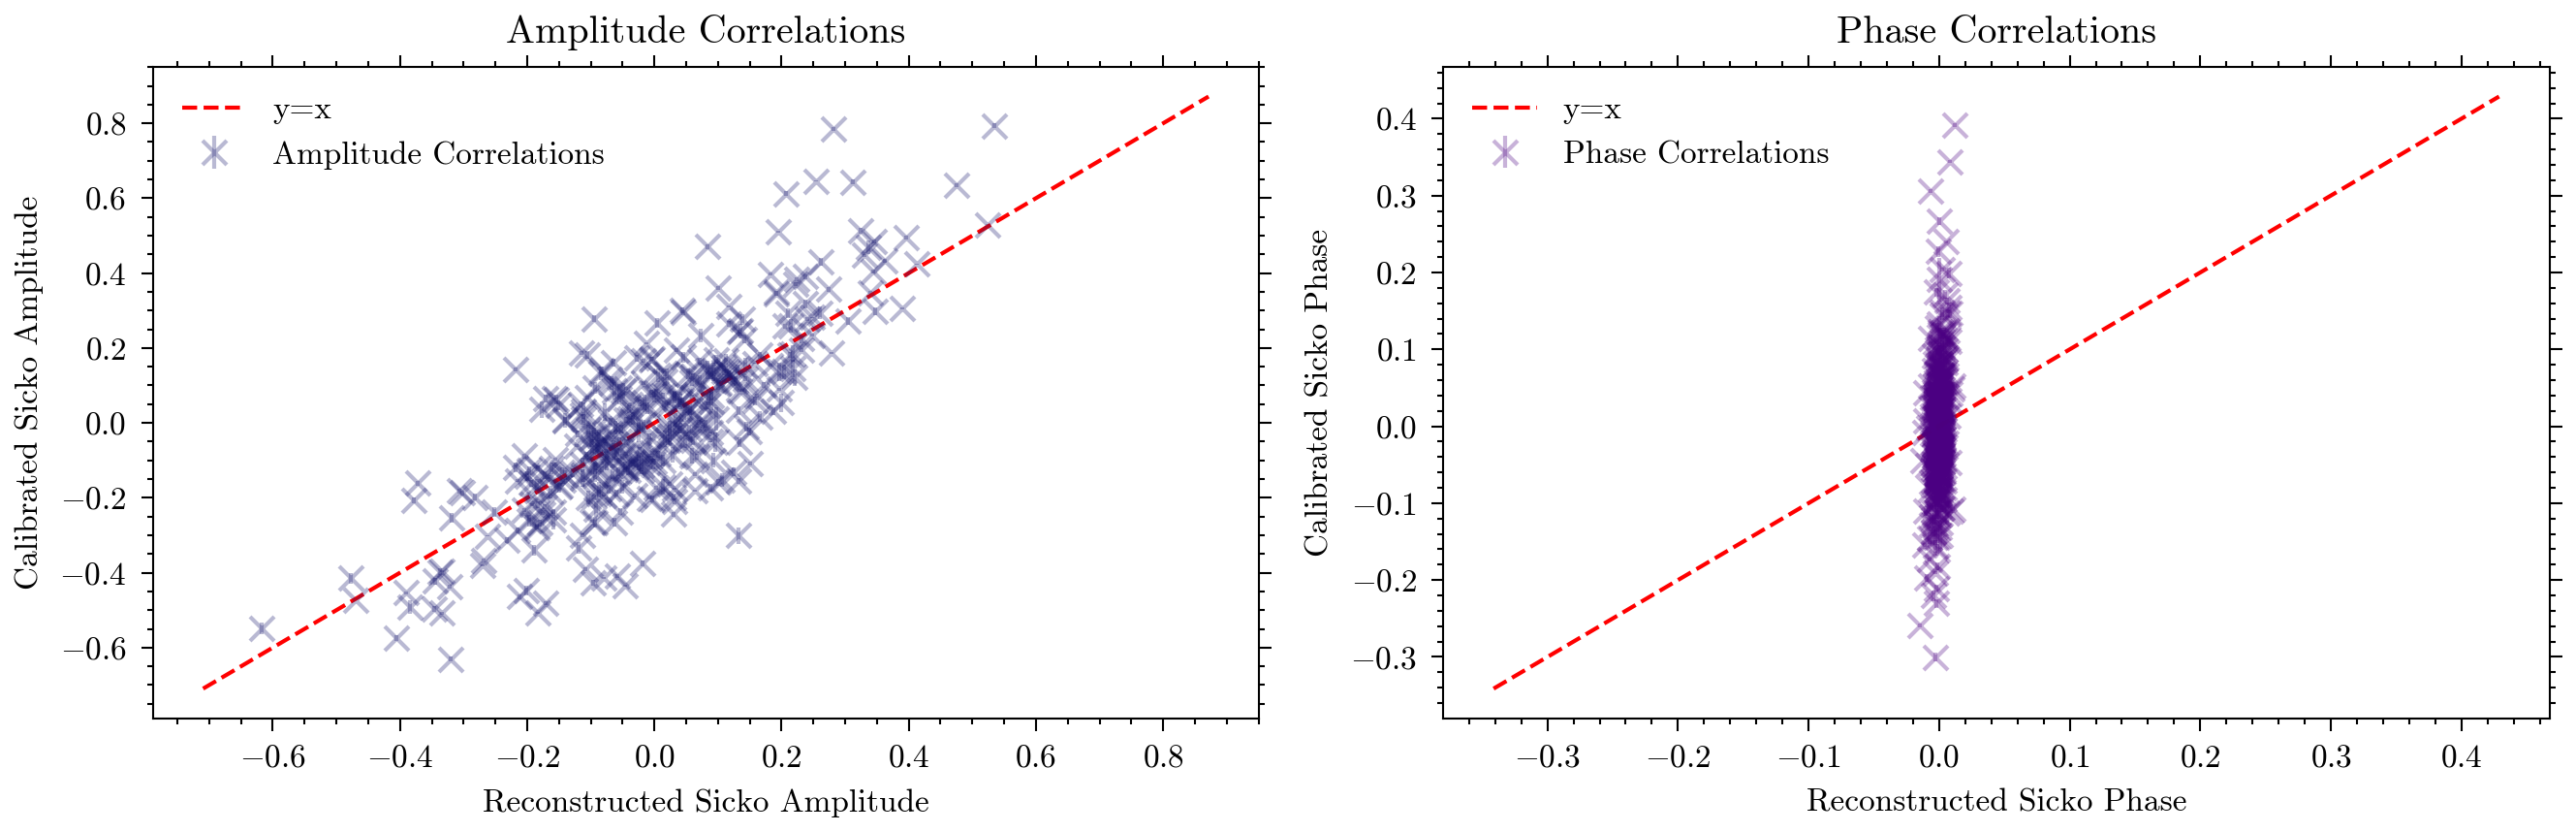

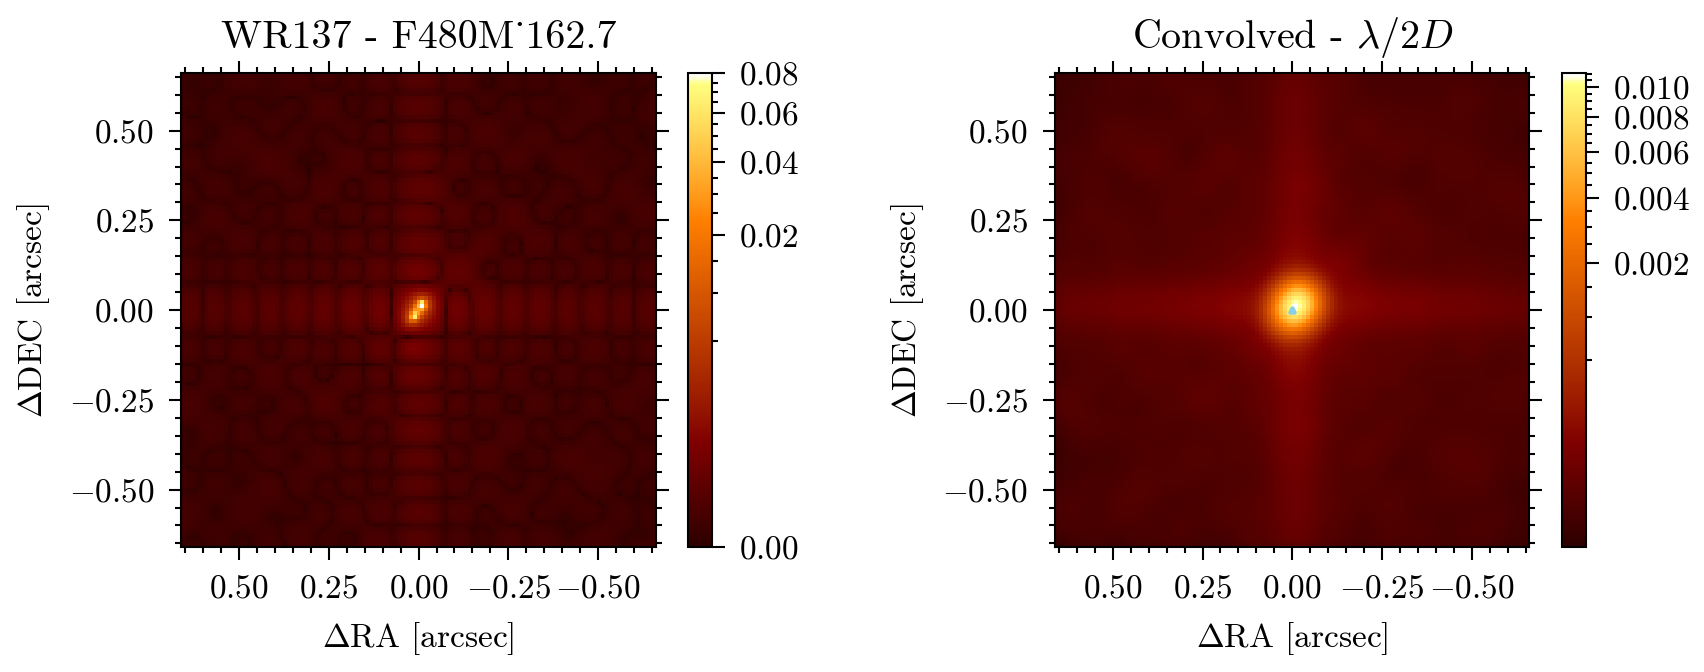

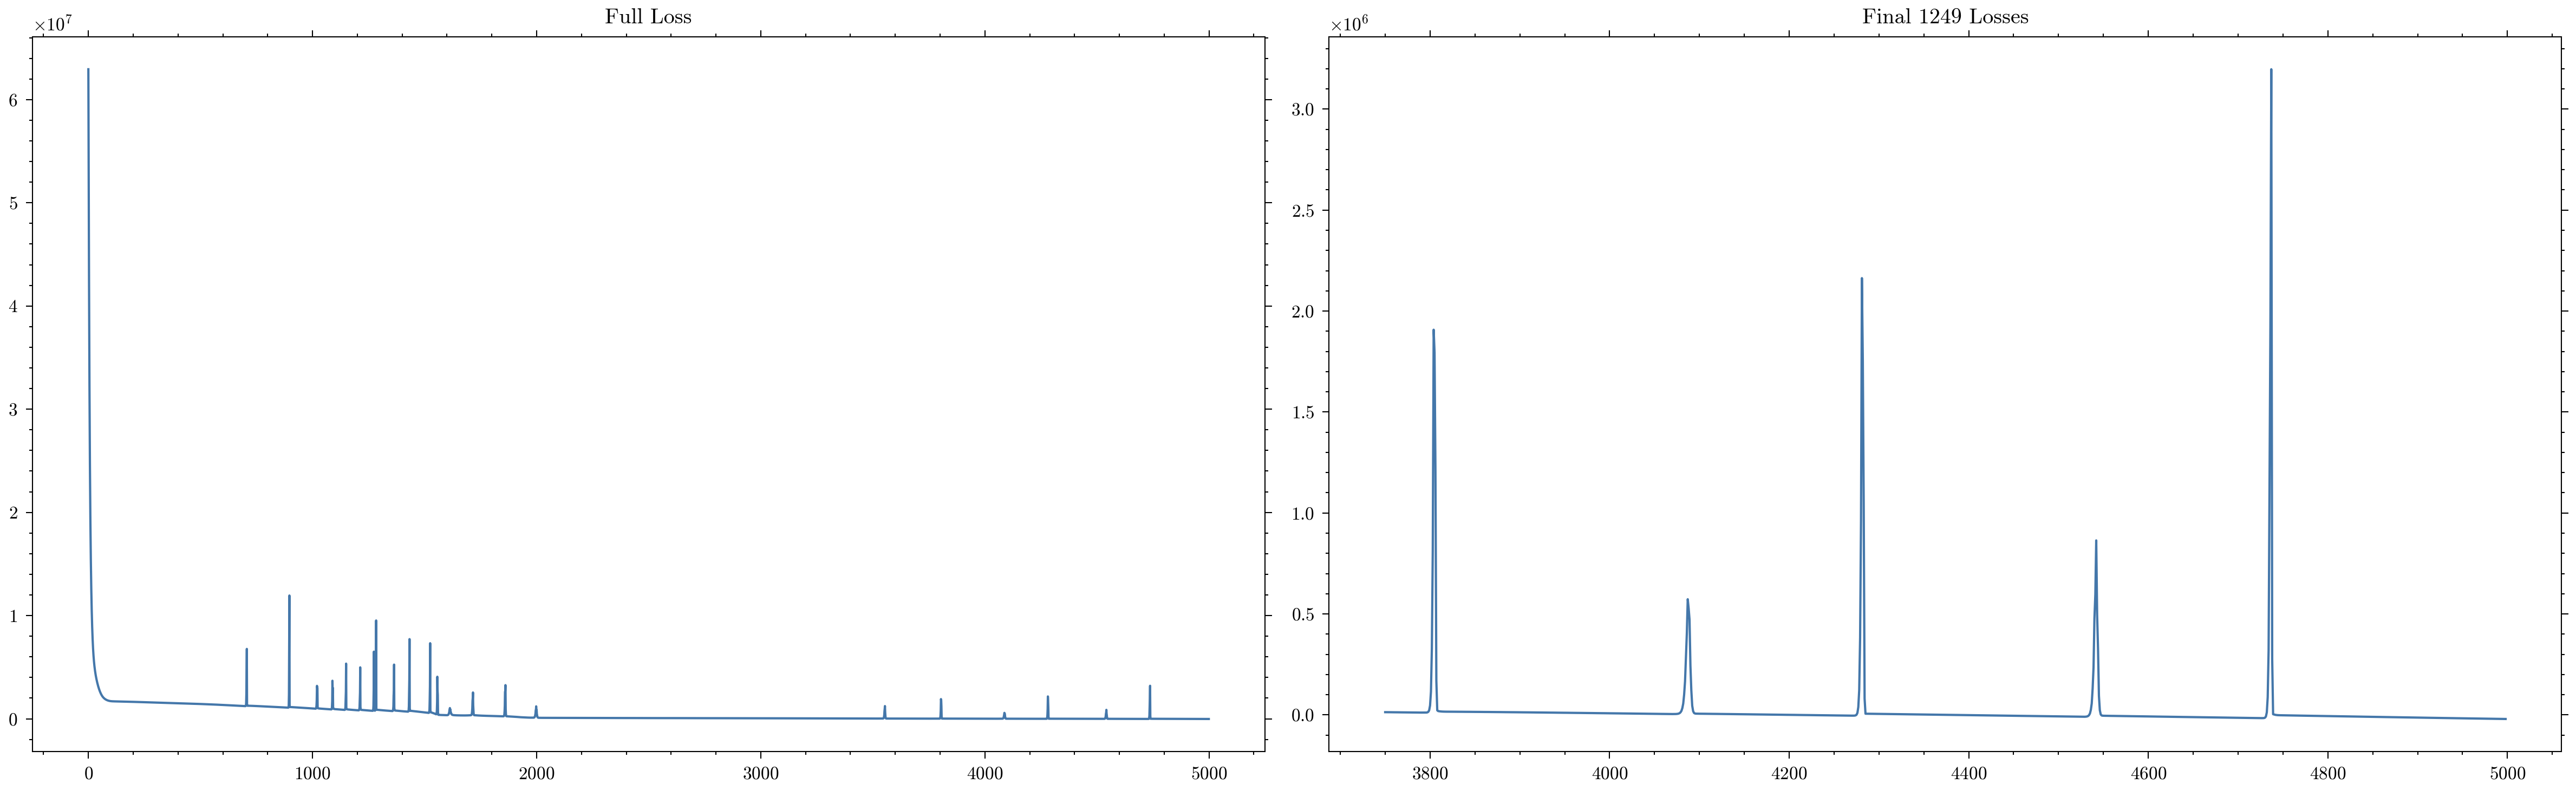

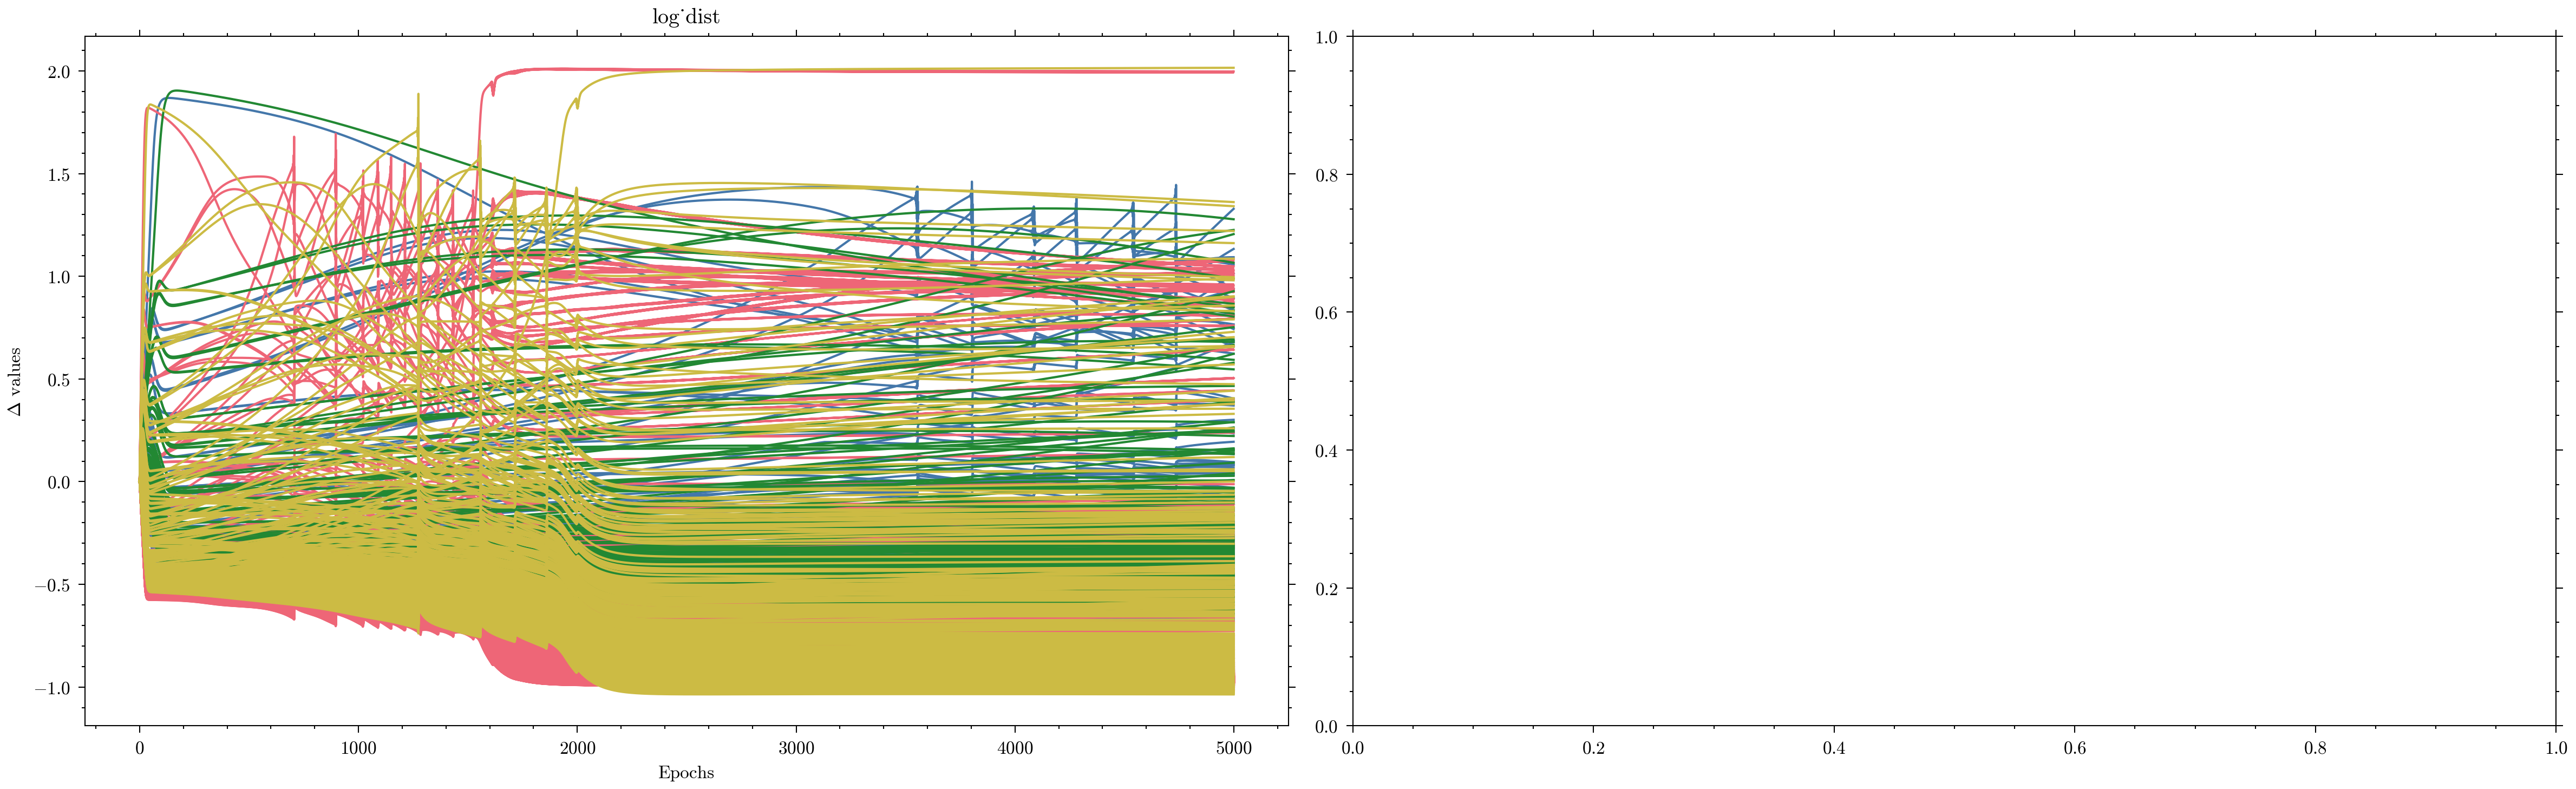

In [ ]:
for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(result.model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, -0.25, 0, 0.25, 0.5]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=0,
        ticks=ticks,
    )
    # ax[0].scatter([0], [0], marker="^", color="skyblue", s=1)

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=None,
        ticks=ticks,
    )
    ax[1].scatter([0], [0], marker="^", color="skyblue", s=1)
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"WR137 - {oi.key}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

In [ ]:
bfgs_model = BFGS_logdist(
    model=result.model, exposures=ois, reg_args=args, max_steps=2**16
)

Initial loss: -11392.364293631792
Final loss: -435250.17174596526
29860 14911




In [ ]:
print(bfgs_model.get_distribution(ois[0]).sum())
print(phase_centre(bfgs_model, ois[0]))

NameError: name 'bfgs_model' is not defined

In [ ]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

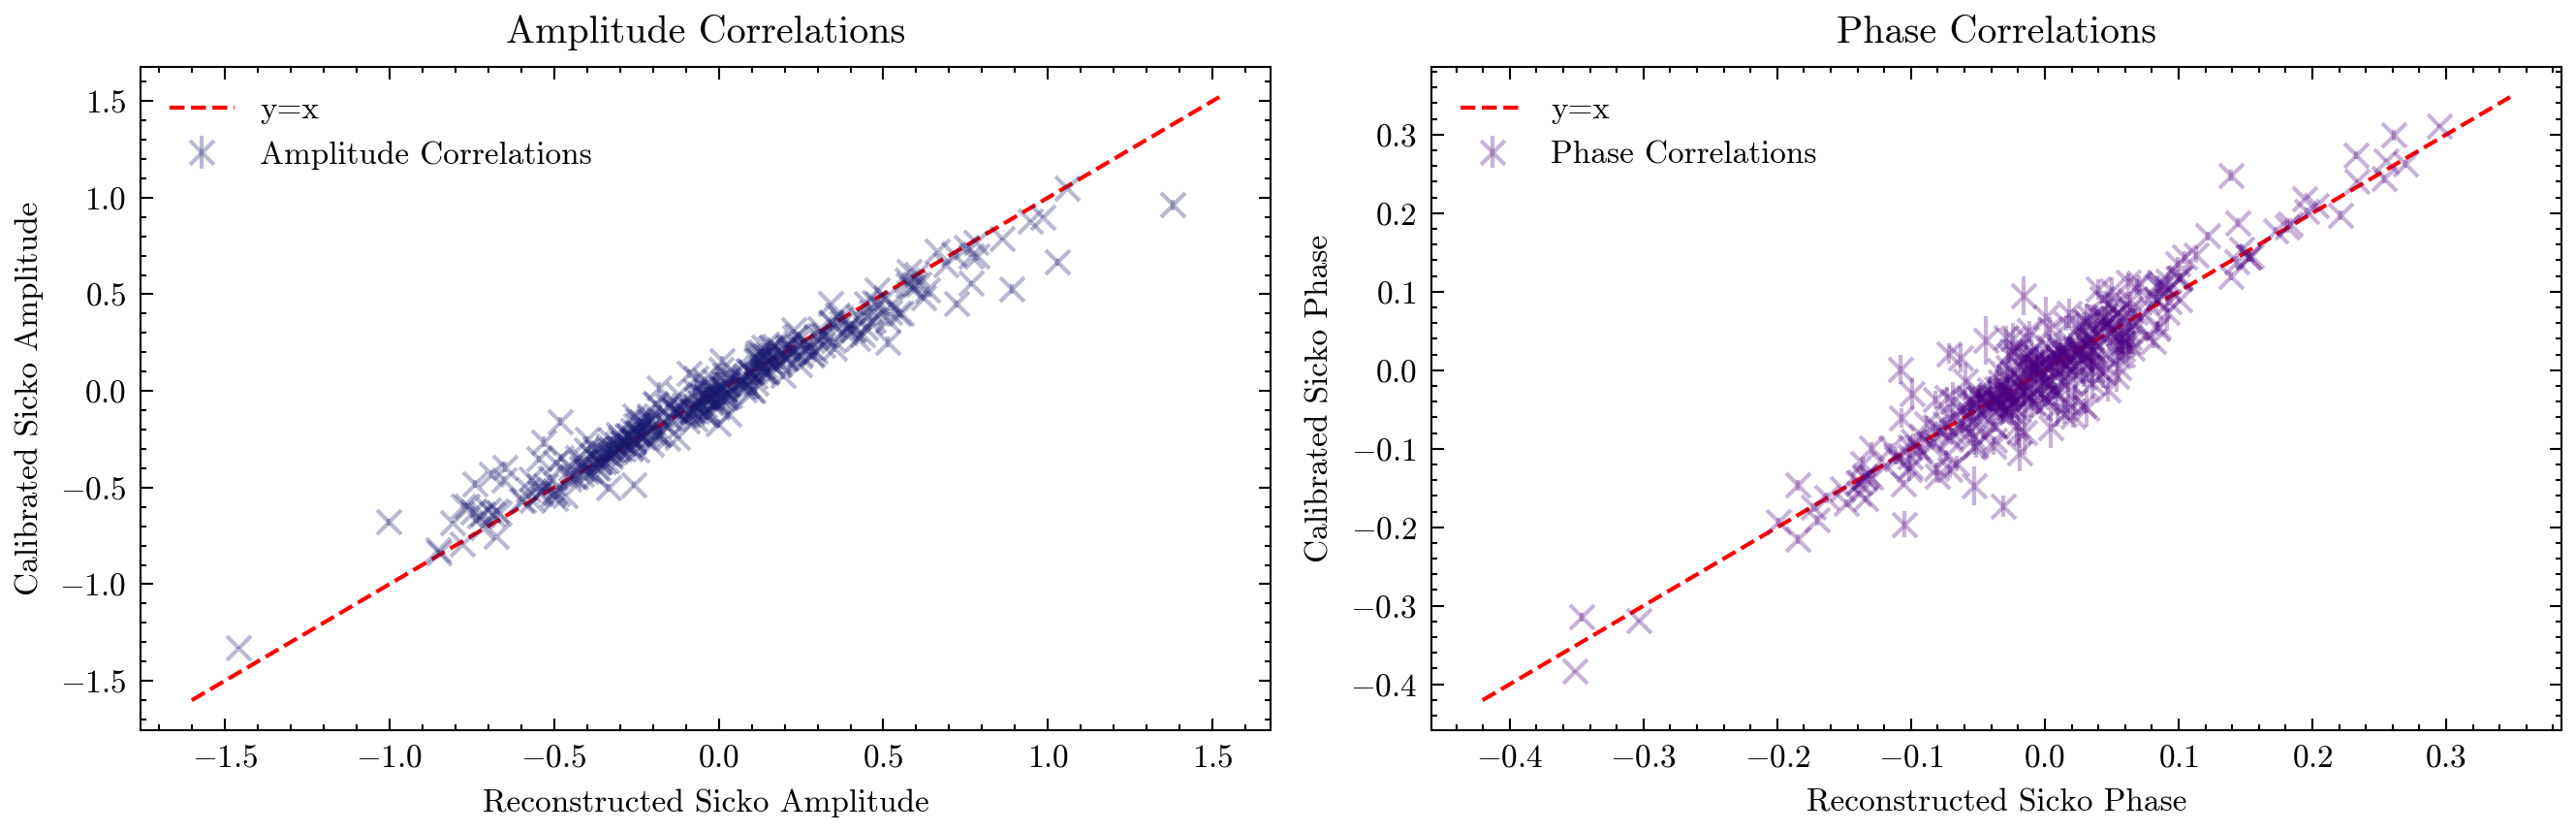

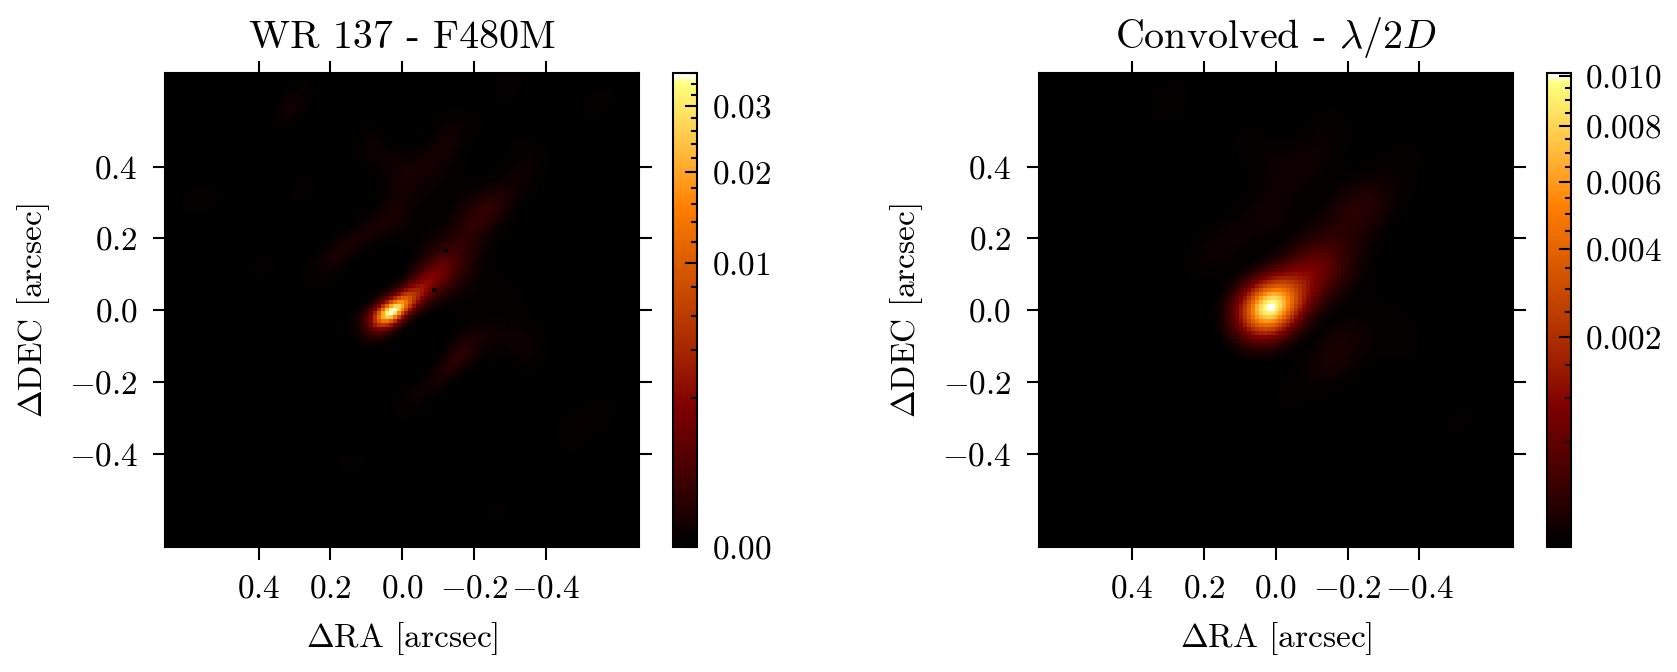

1.0001451214143606


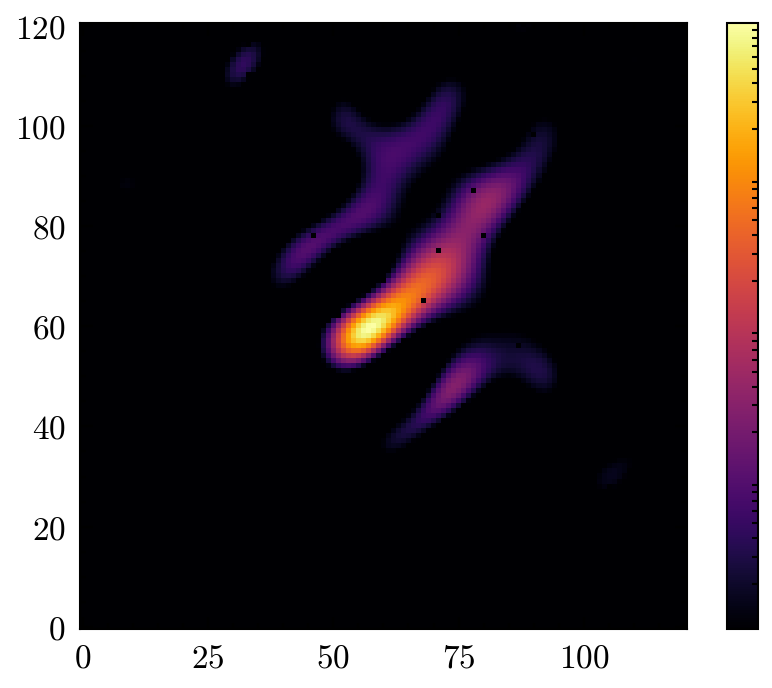

: 

In [ ]:
for oi in ois:
    dist = 10 ** bfgs_model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(bfgs_model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.4, -0.2, 0, 0.2, 0.4]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.4,
        vmin=0,
        ticks=ticks,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.5,
        vmin=None,
        ticks=ticks,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"WR 137 - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

    print(dist.sum())

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()
    plt.imshow(rl_dist, norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0))
    plt.colorbar(ticks=[])
    plt.show()

In [ ]:
params = bfgs_model.params
for oi in ois:
    dist = 10 ** params["log_dist"][oi.get_key("log_dist")]
    blurred_dist = blur_distribution(dist, bfgs_model, oi, factor=0.01)
    params["log_dist"][oi.get_key("log_dist")] = np.log10(
        blurred_dist / blurred_dist.sum()
    )

reg_model = bfgs_model.set("params", params)

In [ ]:
n_epoch = 15000

config = {
    # "log_dist": sgd(5e-8, 0, (500, 0.5)),
    # "log_dist": sgd(3e-800, 0),
    "log_dist": sgd(1e-8, 0),
    # "log_dist": sgd(1e-8, 0, (100, 10), (2000, 0.5)),
    # "log_dist": adam(1e-2, 0, (500, 2)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        # "ME": 5e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 1e12,
        "TSV": 5e6,
    },
}

trainer = amigo.fitting.Trainer(
    loss_fn=regularised_loss_fn,
    cache=fisher_cache,
    # grad_fn=grad_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=reg_model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=reg_model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 123,016,527.74
Estimated run time: 0:01:24


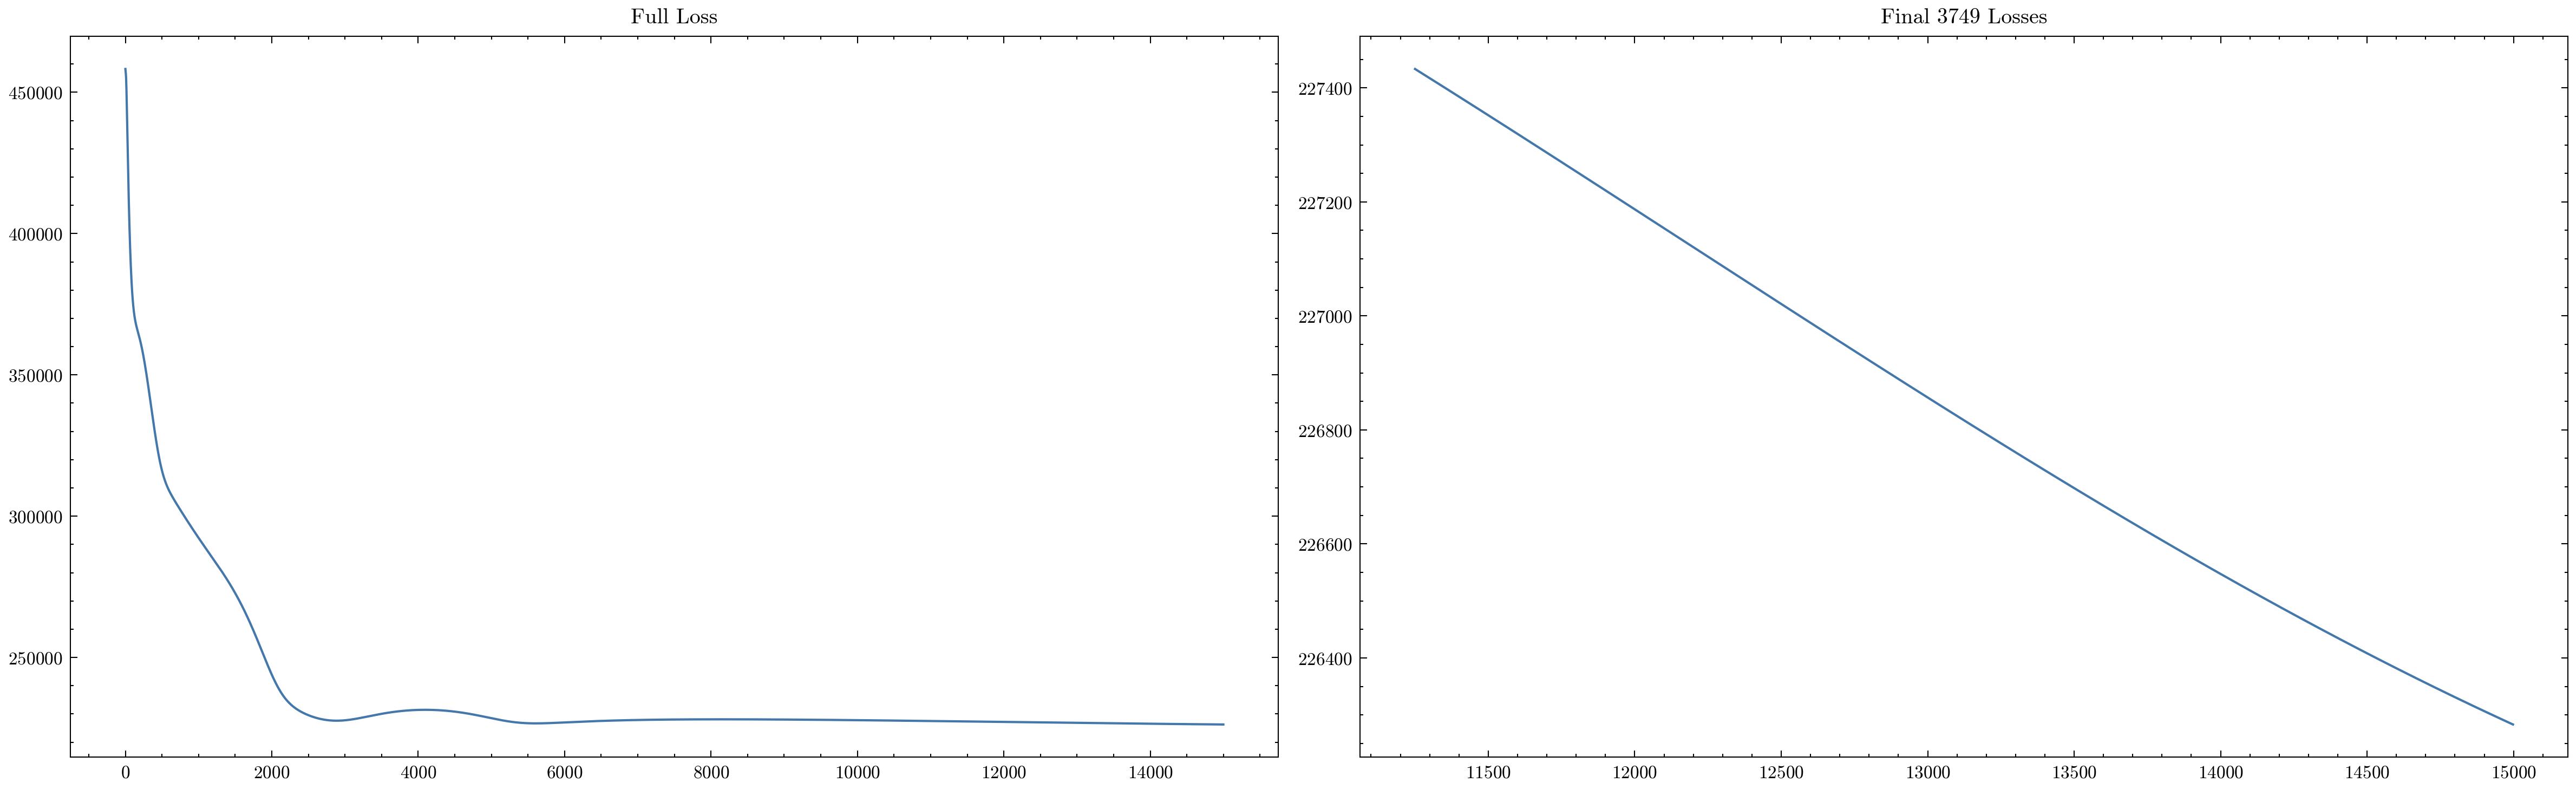

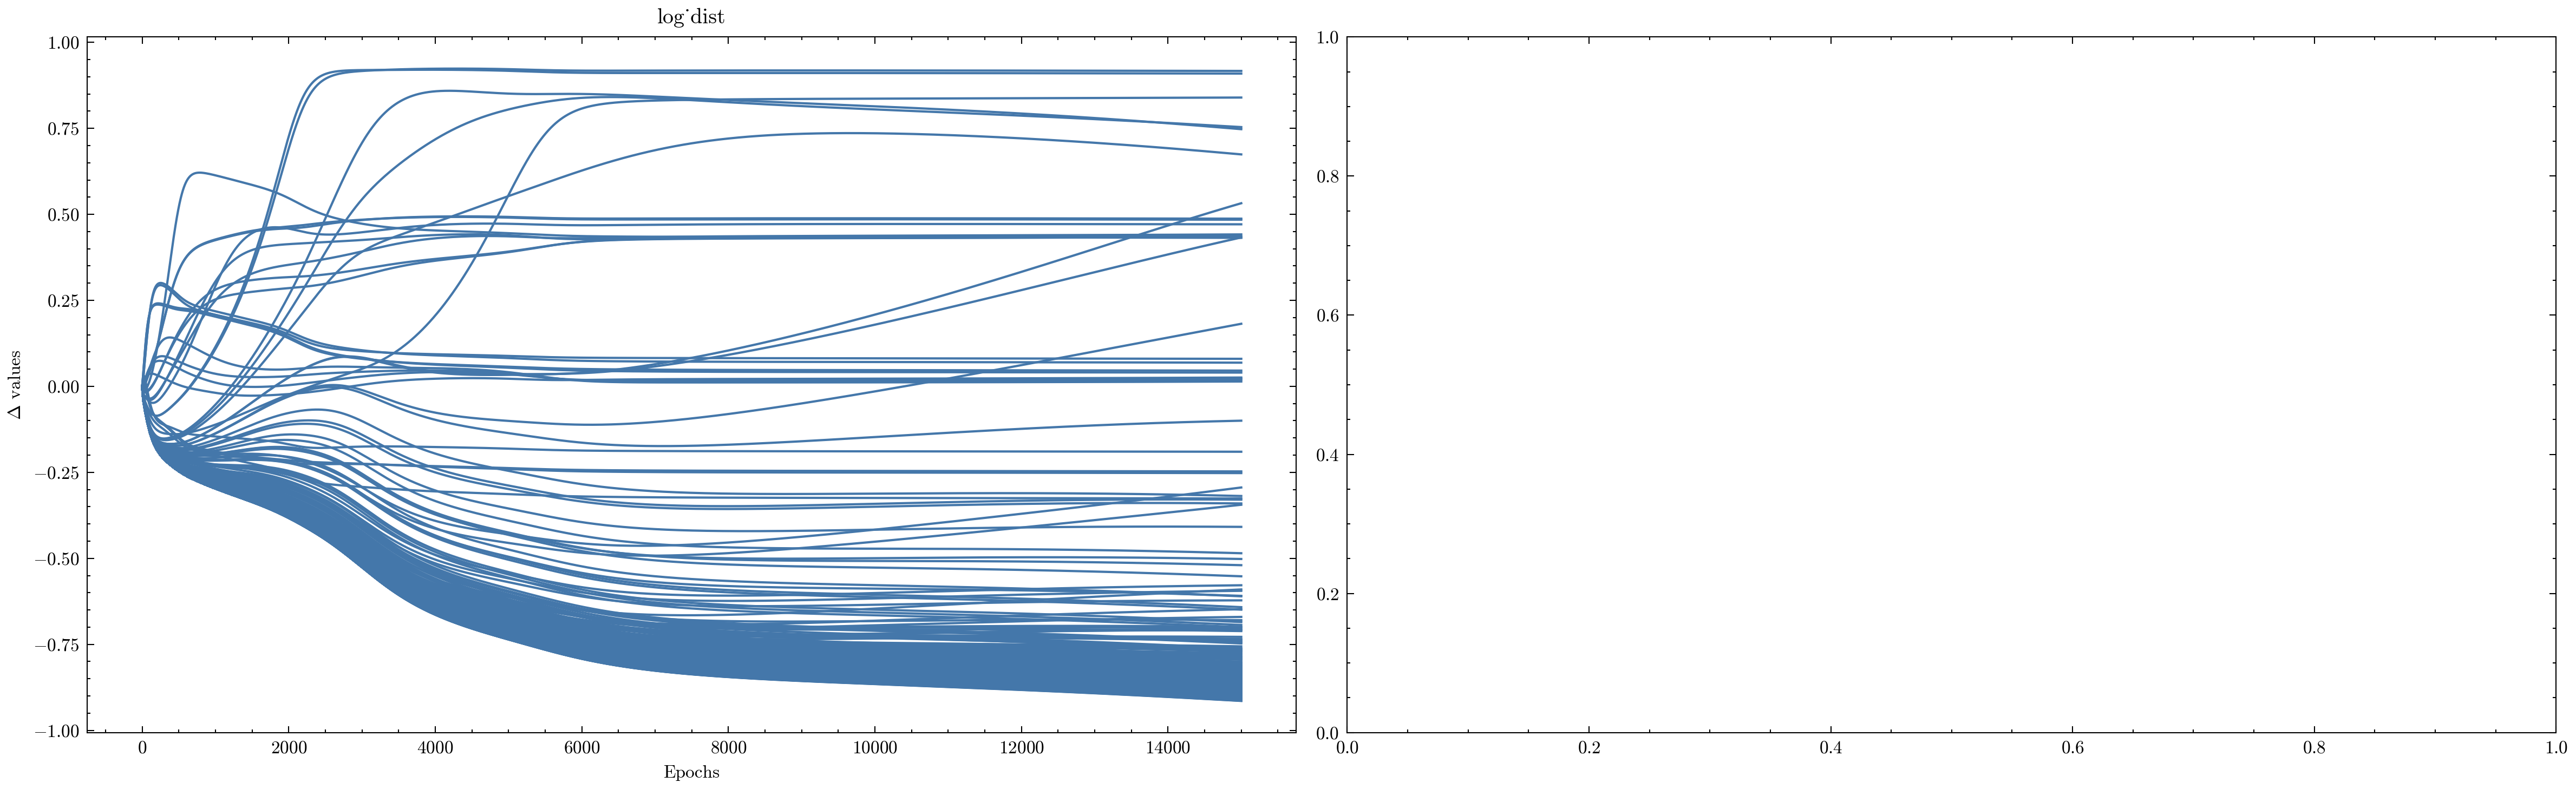

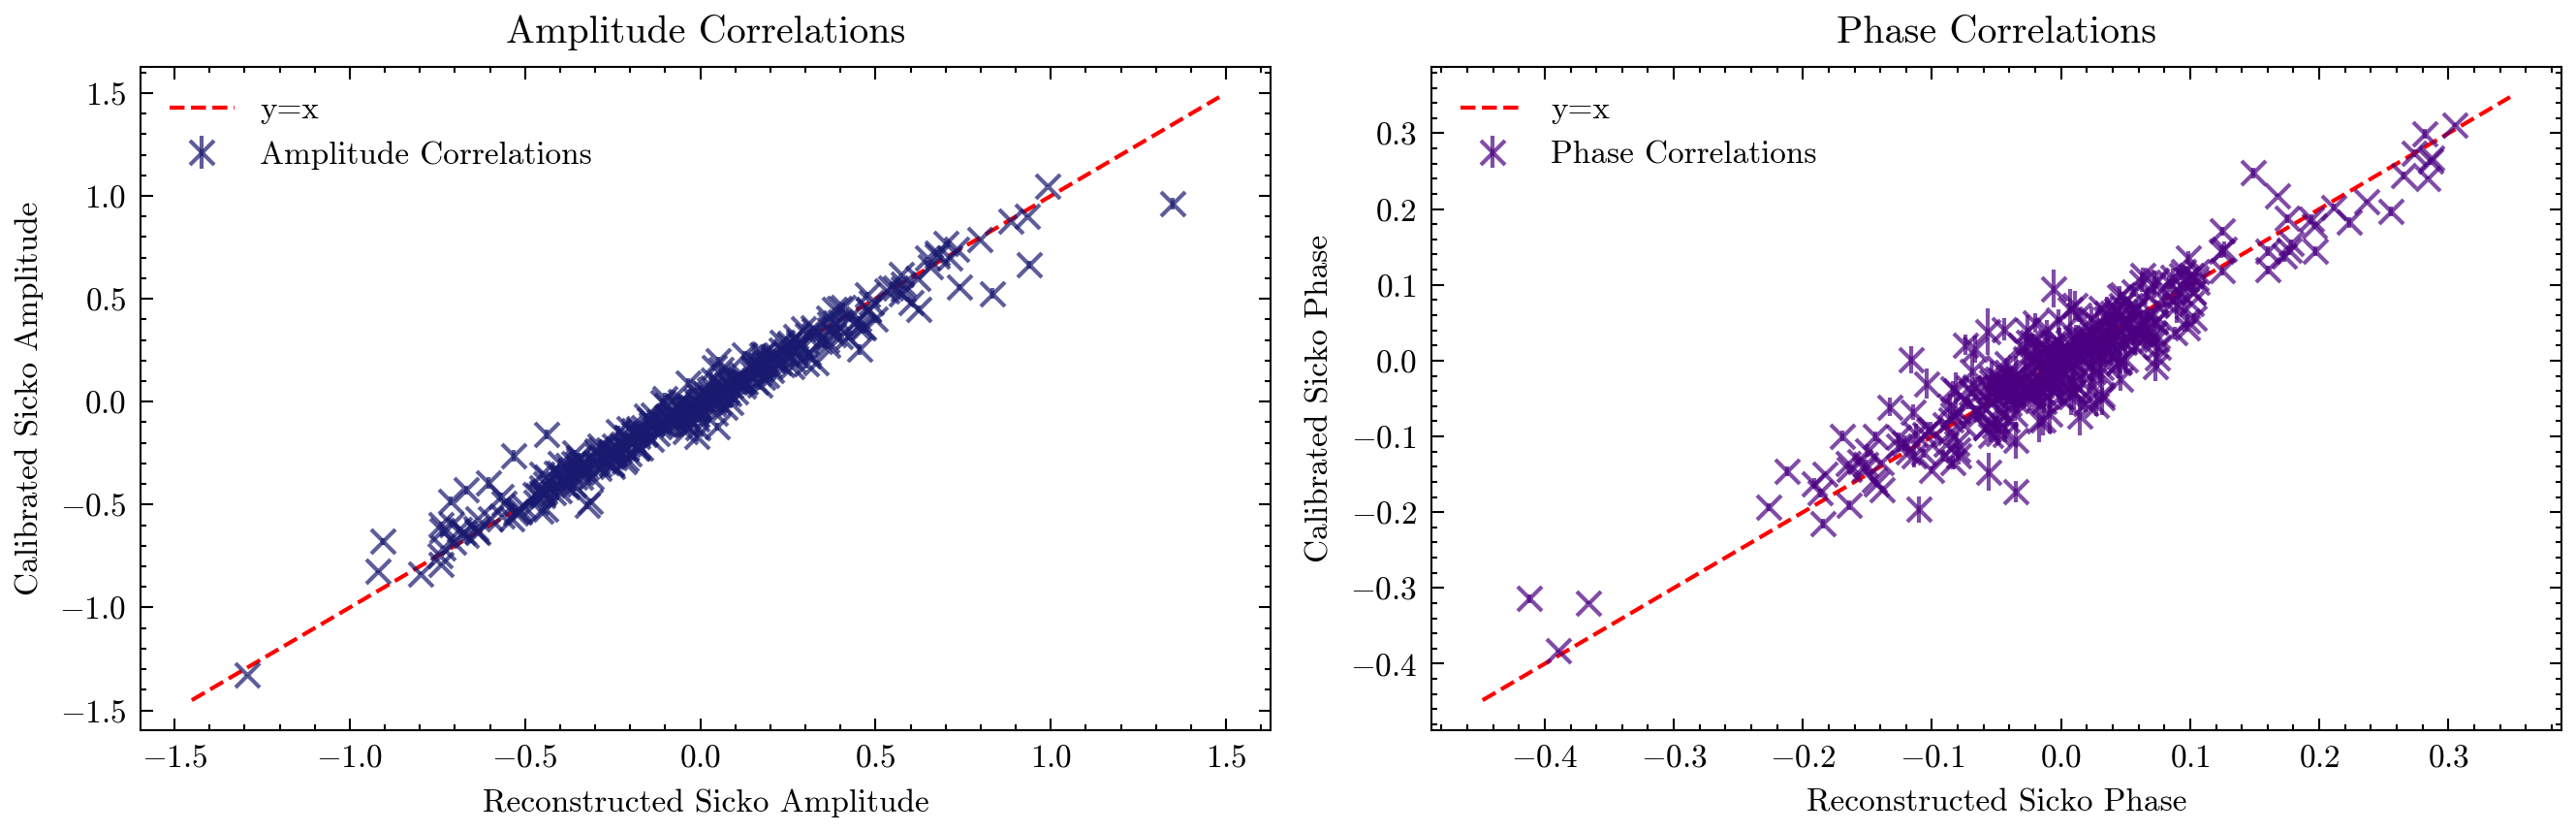

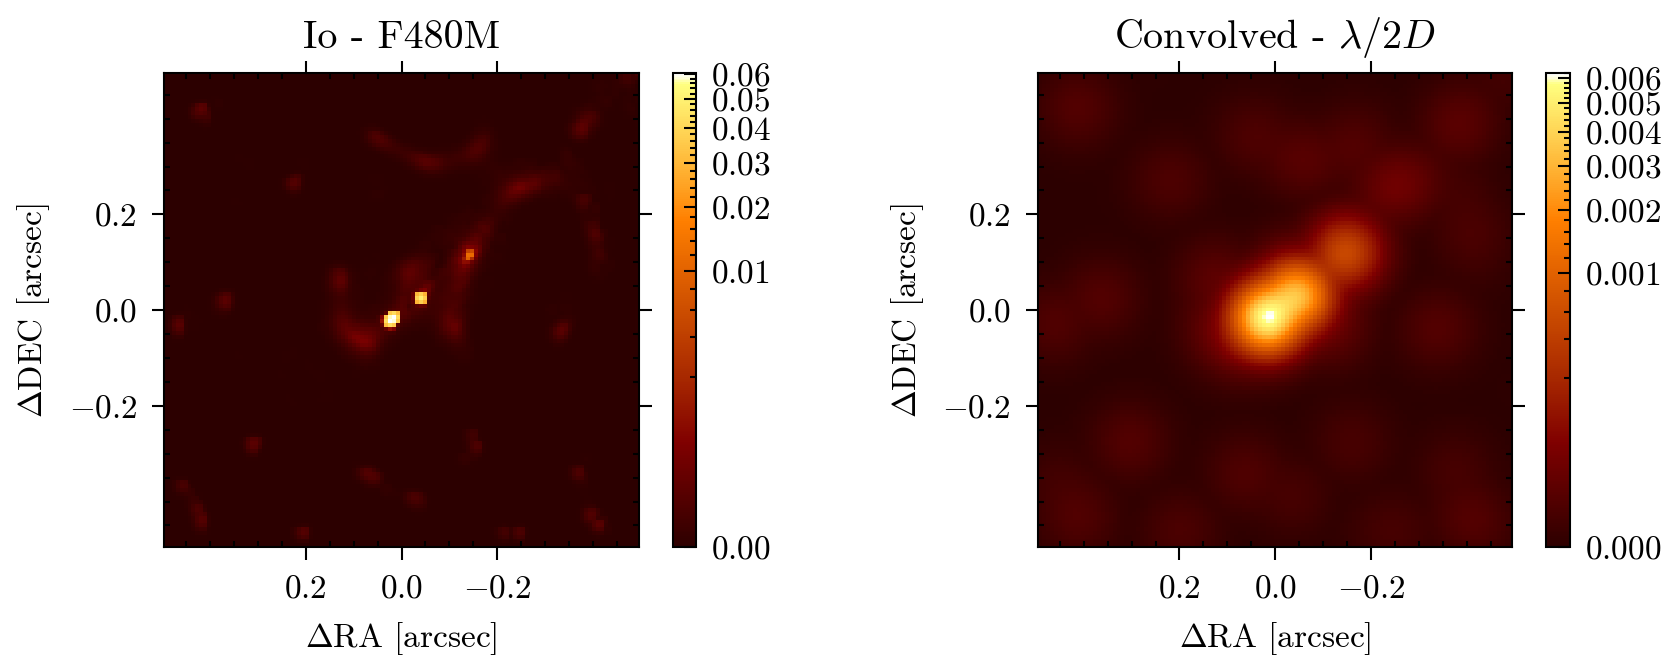

In [ ]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(result.model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.7,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.7,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.2, 0, 0.2]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=0,
        ticks=ticks,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=None,
        ticks=ticks,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"Io - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

In [ ]:
last_model = BFGS_logdist(
    model=result.model,
    exposures=ois,
    reg_args=args,
    max_steps=2**16,
)

Initial loss: 226282.70181366627


E0514 15:47:42.703019 2159313 pjrt_stream_executor_client.cc:2839] Execution of replica 0 failed: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
  File "/me

EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/optimistix/_minimise.py", line 107, in minimise
    return iterative_solve(
           ^^^^^^^^^^^^^^^^
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/optimistix/_iterate.py", line 351, in iterative_solve
    sol = result.error_if(sol, result != RESULTS.successful)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
equinox.EquinoxRuntimeError: The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.

-------------------

An error occurred during the runtime of your JAX program.

1) Setting the environment variable `EQX_ON_ERROR=breakpoint` is usually the most useful
way to debug such errors. This can be interacted with using most of the usual commands
for the 